In [1]:
pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [110]:
%pip install streamlit

  Using cached click-8.5.0-py3-none-any.whl.metadata (2.6 kB)
  Using cached pydeck-0.9.3-py2.py3-none-any.whl.metadata (4.2 kB)
  Using cached requests-2.34.2-py3-none-any.whl.metadata (4.8 kB)
  Using cached toml-0.10.2-py2.py3-none-any.whl.metadata (7.1 kB)
  Using cached anyio-4.15.1-py3-none-any.whl.metadata (4.7 kB)
  Using cached python_multipart-0.0.32-py3-none-any.whl.metadata (2.1 kB)
  Using cached itsdangerous-2.2.0-py3-none-any.whl.metadata (1.9 kB)
  Using cached watchdog-6.0.0-py3-none-win_amd64.whl.metadata (44 kB)
  Using cached jsonschema-4.26.0-py3-none-any.whl.metadata (7.6 kB)
  Using cached certifi-2026.7.22-py3-none-any.whl.metadata (2.5 kB)
  Using cached h11-0.16.0-py3-none-any.whl.metadata (8.3 kB)
  Using cached attrs-26.1.0-py3-none-any.whl.metadata (8.8 kB)
  Using cached jsonschema_specifications-2025.9.1-py3-none-any.whl.metadata (2.9 kB)
  Using cached referencing-0.37.0-py3-none-any.whl.metadata (2.8 kB)
   ---------------------------------------- 0.0/1

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


# Phase 1

In [2]:
import pandas as pd
import numpy as np
from pathlib import Path
import sklearn
from sklearn.model_selection import train_test_split

# Update this path if your RecipeIQ folder is elsewhere
DATA_DIR = Path(
    r"C:\Users\Mastm\OneDrive\Documents\AnC Essentials\RecipeIQ"
)

# Load the original processed interaction splits
train_raw = pd.read_csv(DATA_DIR / "interactions_train.csv")
val_raw = pd.read_csv(DATA_DIR / "interactions_validation.csv")
test_raw = pd.read_csv(DATA_DIR / "interactions_test.csv")

# Keep the original files unchanged and combine copies
all_interactions = pd.concat(
    [train_raw, val_raw, test_raw],
    ignore_index=True
)

# Keep only the columns needed for this experiment
all_interactions = all_interactions[
    ["user_id", "recipe_id", "date", "rating", "u", "i"]
].copy()

# Check basic data quality
print("Combined interaction shape:", all_interactions.shape)
print("\nMissing values:")
print(all_interactions.isna().sum())

print("\nDuplicate user-recipe pairs:",
      all_interactions.duplicated(["user_id", "recipe_id"]).sum())

print("\nUnique users:", all_interactions["user_id"].nunique())
print("Unique original recipes:", all_interactions["recipe_id"].nunique())
print("Unique processed users:", all_interactions["u"].nunique())
print("Unique processed recipes:", all_interactions["i"].nunique())

print("\nRating distribution:")
print(all_interactions["rating"].value_counts().sort_index())

Combined interaction shape: (718379, 6)

Missing values:
user_id      0
recipe_id    0
date         0
rating       0
u            0
i            0
dtype: int64

Duplicate user-recipe pairs: 0

Unique users: 25076
Unique original recipes: 178265
Unique processed users: 25076
Unique processed recipes: 178265

Rating distribution:
rating
0.0     18000
1.0      3722
2.0      7336
3.0     27058
4.0    131846
5.0    530417
Name: count, dtype: int64


In [3]:
SEED = 42
rng = np.random.default_rng(SEED)

interactions = all_interactions.copy()

# Ratings 4–5 represent positive feedback
interactions["label"] = (
    interactions["rating"] >= 4
).astype("int8")

train_parts = []
validation_parts = []
test_parts = []

for user_id, group in interactions.groupby("u", sort=False):

    # Shuffle each user's interactions reproducibly
    group = group.iloc[
        rng.permutation(len(group))
    ]

    n = len(group)

    # Too few interactions for three non-empty sets
    if n < 3:
        train_parts.append(group)
        continue

    # Reserve at least one interaction for validation and test
    n_holdout = max(2, round(n * 0.20))
    n_holdout = min(n_holdout, n - 1)

    n_test = n_holdout // 2
    n_val = n_holdout - n_test

    train_end = n - n_holdout
    val_end = train_end + n_val

    train_parts.append(group.iloc[:train_end])
    validation_parts.append(group.iloc[train_end:val_end])
    test_parts.append(group.iloc[val_end:])

train_custom = pd.concat(train_parts, ignore_index=True)

validation_custom = pd.concat(
    validation_parts, ignore_index=True
)

test_custom = pd.concat(test_parts, ignore_index=True)

print("Train:", train_custom.shape)
print("Validation:", validation_custom.shape)
print("Test:", test_custom.shape)

Train: (564193, 7)
Validation: (79368, 7)
Test: (74818, 7)


In [4]:
# 1. Checking user and recipe coverage

train_users = set(train_custom["u"].unique())
val_users = set(validation_custom["u"].unique())
test_users = set(test_custom["u"].unique())

train_recipes = set(train_custom["i"].unique())
val_recipes = set(validation_custom["i"].unique())
test_recipes = set(test_custom["i"].unique())

print("========== USER COVERAGE ==========")
print("Train users:", len(train_users))
print("Validation users:", len(val_users))
print("Test users:", len(test_users))

print("Validation users unseen in training:",
      len(val_users - train_users))
print("Test users unseen in training:",
      len(test_users - train_users))

print("\n========== RECIPE COVERAGE ==========")
print("Train recipes:", len(train_recipes))
print("Validation recipes:", len(val_recipes))
print("Test recipes:", len(test_recipes))

print("Validation recipes unseen in training:",
      len(val_recipes - train_recipes))
print("Test recipes unseen in training:",
      len(test_recipes - train_recipes))

========== USER COVERAGE ==========
Train users: 25076
Validation users: 22114
Test users: 22114
Validation users unseen in training: 0
Test users unseen in training: 0

========== RECIPE COVERAGE ==========
Train recipes: 158801
Validation recipes: 46739
Test recipes: 45139
Validation recipes unseen in training: 10433
Test recipes unseen in training: 9945


In [5]:
# 2. Checking whether user-recipe pairs overlap across splits

train_pairs = set(zip(train_custom["u"], train_custom["i"]))
val_pairs = set(zip(validation_custom["u"], validation_custom["i"]))
test_pairs = set(zip(test_custom["u"], test_custom["i"]))

print("\n========== PAIR LEAKAGE CHECK ==========")
print("Train-validation shared pairs:", len(train_pairs & val_pairs))
print("Train-test shared pairs:", len(train_pairs & test_pairs))
print("Validation-test shared pairs:", len(val_pairs & test_pairs))


========== PAIR LEAKAGE CHECK ==========
Train-validation shared pairs: 0
Train-test shared pairs: 0
Validation-test shared pairs: 0


In [6]:
# 3. Checking positive and negative labels
for split_name, df in [
    ("Train", train_custom),
    ("Validation", validation_custom),
    ("Test", test_custom)
]:
    print(f"\n{split_name} label distribution:")
    print(df["label"].value_counts().sort_index())
    print(f"{split_name} positive rate: {df['label'].mean():.2%}")


Train label distribution:
label
0     43582
1    520611
Name: count, dtype: int64
Train positive rate: 92.28%

Validation label distribution:
label
0     6594
1    72774
Name: count, dtype: int64
Validation positive rate: 91.69%

Test label distribution:
label
0     5940
1    68878
Name: count, dtype: int64
Test positive rate: 92.06%


In [7]:
# 1. Positive training interactions
positive_train = train_custom[
    train_custom["label"] == 1
].copy()

In [8]:
# 2. Recipes available to the trained NCF model
train_recipe_ids = set(positive_train["i"].unique())

In [9]:
# 3. Positive validation/test targets whose recipes are known
validation_positive = validation_custom[
    (validation_custom["label"] == 1) &
    (validation_custom["i"].isin(train_recipe_ids))
].copy()

test_positive = test_custom[
    (test_custom["label"] == 1) &
    (test_custom["i"].isin(train_recipe_ids))
].copy()

In [10]:
# 4. Summarize evaluation coverage
for name, original, eligible in [
    ("Validation", validation_custom, validation_positive),
    ("Test", test_custom, test_positive)
]:
    original_positive = original[original["label"] == 1]

    print(f"\n========== {name} ==========")
    print("All interactions:", len(original))
    print("Positive interactions:", len(original_positive))
    print("Eligible positive targets:", len(eligible))
    print("Unique eligible users:", eligible["u"].nunique())
    print("Positive targets excluded:",
          len(original_positive) - len(eligible))
    print(
        "Positive-target coverage:",
        f"{len(eligible) / max(len(original_positive), 1):.2%}"
    )


========== Validation ==========
All interactions: 79368
Positive interactions: 72774
Eligible positive targets: 62464
Unique eligible users: 18518
Positive targets excluded: 10310
Positive-target coverage: 85.83%

========== Test ==========
All interactions: 74818
Positive interactions: 68878
Eligible positive targets: 58974
Unique eligible users: 18273
Positive targets excluded: 9904
Positive-target coverage: 85.62%


In [11]:
# Count positive training interactions per recipe
positive_recipe_counts = (
    positive_train.groupby("i")
    .size()
    .rename("positive_train_count")
)

# Examine how many recipes have very little positive history
print("Recipes with 1 positive training interaction:",
      (positive_recipe_counts == 1).sum())

print("Recipes with fewer than 3 positive training interactions:",
      (positive_recipe_counts < 3).sum())

print("Recipes with fewer than 5 positive training interactions:",
      (positive_recipe_counts < 5).sum())

print("\nPositive training interactions per recipe:")
print(positive_recipe_counts.describe(
    percentiles=[0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
))

Recipes with 1 positive training interaction: 74181
Recipes with fewer than 3 positive training interactions: 102365
Recipes with fewer than 5 positive training interactions: 125421

Positive training interactions per recipe:
count    149952.000000
mean          3.471851
std           9.853101
min           1.000000
25%           1.000000
50%           2.000000
75%           3.000000
90%           6.000000
95%          10.000000
99%          30.000000
max         726.000000
Name: positive_train_count, dtype: float64


In [12]:
# Recipe IDs observed in any training interaction
all_train_recipe_ids = set(train_custom["i"].unique())

# Recipe IDs with at least one positive training interaction
positive_train_recipe_ids = set(positive_train["i"].unique())

for name, df in [
    ("Validation", validation_custom),
    ("Test", test_custom)
]:
    positives = df[df["label"] == 1]

    seen_any = positives["i"].isin(
        all_train_recipe_ids
    )

    seen_positive = positives["i"].isin(
        positive_train_recipe_ids
    )

    print(f"\n========== {name} ==========")
    print("Total positive targets:", len(positives))

    print(
        "Targets whose recipes appeared in any training interaction:",
        int(seen_any.sum())
    )
    print(
        "Coverage using any training interaction:",
        f"{seen_any.mean():.2%}"
    )

    print(
        "Targets whose recipes had positive training history:",
        int(seen_positive.sum())
    )
    print(
        "Coverage using positive training history:",
        f"{seen_positive.mean():.2%}"
    )


========== Validation ==========
Total positive targets: 72774
Targets whose recipes appeared in any training interaction: 63103
Coverage using any training interaction: 86.71%
Targets whose recipes had positive training history: 62464
Coverage using positive training history: 85.83%

========== Test ==========
Total positive targets: 68878
Targets whose recipes appeared in any training interaction: 59583
Coverage using any training interaction: 86.51%
Targets whose recipes had positive training history: 58974
Coverage using positive training history: 85.62%


In [13]:

# STEP: Prepare warm-start evaluation targets

# Positive interactions only (ratings 4 and 5)
train_positive = train_custom.loc[train_custom["label"] == 1].copy()
validation_positive = validation_custom.loc[
    validation_custom["label"] == 1
].copy()
test_positive = test_custom.loc[
    test_custom["label"] == 1
].copy()

# Users and recipes with positive training history
train_positive_users = set(train_positive["u"].unique())
train_positive_recipes = set(train_positive["i"].unique())

# Keep targets only when BOTH user and recipe have positive
# training history
validation_targets = validation_positive[
    validation_positive["u"].isin(train_positive_users)
    & validation_positive["i"].isin(train_positive_recipes)
].copy()

test_targets = test_positive[
    test_positive["u"].isin(train_positive_users)
    & test_positive["i"].isin(train_positive_recipes)
].copy()

print("========== FINAL WARM-START TARGETS ==========")
print("Positive training interactions:", len(train_positive))
print("Validation targets:", len(validation_targets))
print("Test targets:", len(test_targets))

print("Validation users:", validation_targets["u"].nunique())
print("Test users:", test_targets["u"].nunique())

print(
    "Validation target coverage:",
    f"{len(validation_targets) / len(validation_positive):.2%}"
)
print(
    "Test target coverage:",
    f"{len(test_targets) / len(test_positive):.2%}"
)

# Confirm the target users and recipes are known to training
assert validation_targets["u"].isin(train_positive_users).all()
assert validation_targets["i"].isin(train_positive_recipes).all()
assert test_targets["u"].isin(train_positive_users).all()
assert test_targets["i"].isin(train_positive_recipes).all()

print("All warm-start checks passed.")

========== FINAL WARM-START TARGETS ==========
Positive training interactions: 520611
Validation targets: 62128
Test targets: 58646
Validation users: 18182
Test users: 17945
Validation target coverage: 85.37%
Test target coverage: 85.14%
All warm-start checks passed.


In [14]:
# Check the training labels before negative sampling

print("Training data shape:", train_custom.shape)

print("\nLabel distribution:")
print(train_custom["label"].value_counts().sort_index())

print("\nLabel percentages:")
print(
    (train_custom["label"].value_counts(normalize=True)
     .sort_index() * 100).round(2)
)

print("\nUnique users:", train_custom["u"].nunique())
print("Unique recipes:", train_custom["i"].nunique())

print("\nDuplicate user-recipe pairs:",
      train_custom.duplicated(["u", "i"]).sum())

Training data shape: (564193, 7)

Label distribution:
label
0     43582
1    520611
Name: count, dtype: int64

Label percentages:
label
0     7.72
1    92.28
Name: proportion, dtype: float64

Unique users: 25076
Unique recipes: 158801

Duplicate user-recipe pairs: 0


In [15]:
from pathlib import Path
import pandas as pd
import numpy as np

# Use a raw string (r"...") to avoid Windows backslash errors
DATA_DIR = Path(
    r"C:\Users\Mastm\OneDrive\Documents\AnC Essentials\RecipeIQ"
)

# Load the processed recipe catalog
recipes = pd.read_csv(
    DATA_DIR / "PP_recipes.csv",
    usecols=["i"]
)

catalog_items = np.sort(recipes["i"].dropna().unique())

print("Recipe catalog loaded successfully.")
print("Catalog recipes:", len(catalog_items))
print("Missing recipe indices:", recipes["i"].isna().sum())
print("Duplicate catalog indices:", recipes["i"].duplicated().sum())

Recipe catalog loaded successfully.
Catalog recipes: 178265
Missing recipe indices: 0
Duplicate catalog indices: 0


In [16]:
# STEP 2A: Building the catalog and known-interaction lookup

from pathlib import Path
import pandas as pd
import numpy as np

SEED = 42
rng = np.random.default_rng(SEED)

DATA_DIR = Path(
    r"C:\Users\Mastm\OneDrive\Documents\AnC Essentials\RecipeIQ"
)

# Load processed recipe indices
recipe_catalog = pd.read_csv(
    DATA_DIR / "PP_recipes.csv",
    usecols=["i"]
)

catalog_items = np.sort(
    recipe_catalog["i"].dropna().unique()
)

# Collect interactions from all three splits
all_known_pairs = pd.concat(
    [
        train_custom[["u", "i"]],
        validation_custom[["u", "i"]],
        test_custom[["u", "i"]]
    ],
    ignore_index=True
).drop_duplicates()

# For each user, store every recipe they have interacted with
known_items_by_user = (
    all_known_pairs.groupby("u")["i"]
    .apply(set)
    .to_dict()
)

# Positive interactions in the training split
positive_train = (
    train_custom.loc[
        train_custom["label"] == 1, ["u", "i"]
    ]
    .drop_duplicates()
)

print("Positive training interactions:", len(positive_train))
print("Catalog recipes:", len(catalog_items))
print("Users with known interactions:", len(known_items_by_user))
print("Known user-recipe pairs:", len(all_known_pairs))
print("Duplicate catalog indices:", recipe_catalog["i"].duplicated().sum())

Positive training interactions: 520611
Catalog recipes: 178265
Users with known interactions: 25076
Known user-recipe pairs: 718379
Duplicate catalog indices: 0


In [17]:
# STEP 2B: Checking available negative candidates

catalog_size = len(catalog_items)

available_negative_counts = {
    user: catalog_size - len(known_items)
    for user, known_items in known_items_by_user.items()
}

print(
    "Minimum available unseen recipes:",
    min(available_negative_counts.values())
)

print(
    "Users with no available negative candidates:",
    sum(
        count == 0
        for count in available_negative_counts.values()
    )
)

Minimum available unseen recipes: 171828
Users with no available negative candidates: 0


In [18]:
# STEP 2C: Generated sampled negative interactions

negative_rows = []

# Sample one negative for every positive training interaction
positive_counts = positive_train.groupby("u").size()

for user, n_samples in positive_counts.items():

    known_items = known_items_by_user.get(user, set())
    selected_items = set()

    # Draw candidates in batches until we have enough valid negatives
    while len(selected_items) < n_samples:

        remaining = n_samples - len(selected_items)
        batch_size = max(100, remaining * 3)

        candidates = rng.choice(
            catalog_items,
            size=batch_size,
            replace=True
        )

        for item in candidates:
            item = int(item)

            if item not in known_items and item not in selected_items:
                selected_items.add(item)

                if len(selected_items) == n_samples:
                    break

    negative_rows.extend(
        (int(user), item, 0)
        for item in selected_items
    )

sampled_negatives = pd.DataFrame(
    negative_rows,
    columns=["u", "i", "label"]
)

print("Sampled negatives:", len(sampled_negatives))
print("Expected negatives:", len(positive_train))
print(
    "Duplicate sampled pairs:",
    sampled_negatives.duplicated(["u", "i"]).sum()
)

Sampled negatives: 520611
Expected negatives: 520611
Duplicate sampled pairs: 0


In [19]:
# STEP 2D: Creating the final NCF training dataset

ncf_train = pd.concat(
    [
        train_custom[["u", "i", "label"]],
        sampled_negatives
    ],
    ignore_index=True
)

print("Original training rows:", len(train_custom))
print("Added sampled negatives:", len(sampled_negatives))
print("Final NCF training shape:", ncf_train.shape)

print("\nFinal label counts:")
print(ncf_train["label"].value_counts().sort_index())

print("\nFinal label percentages:")
print(
    (ncf_train["label"].value_counts(normalize=True)
     .sort_index() * 100).round(2)
)

print(
    "\nDuplicate user-recipe pairs:",
    ncf_train.duplicated(["u", "i"]).sum()
)

print(
    "Sampled negatives overlapping known interactions:",
    len(
        sampled_negatives.merge(
            all_known_pairs,
            on=["u", "i"],
            how="inner"
        )
    )
)

Original training rows: 564193
Added sampled negatives: 520611
Final NCF training shape: (1084804, 3)

Final label counts:
label
0    564193
1    520611
Name: count, dtype: int64

Final label percentages:
label
0    52.01
1    47.99
Name: proportion, dtype: float64

Duplicate user-recipe pairs: 0
Sampled negatives overlapping known interactions: 0


## Step 3

In [20]:
import sys

print("Python executable:", sys.executable)
print("Python version:", sys.version)

Python executable: C:\Users\Mastm\anaconda3\envs\recipeiq\python.exe
Python version: 3.11.16 | packaged by Anaconda, Inc. | (main, Aug 27 2026, 14:36:16) [MSC v.1942 64 bit (AMD64)]


In [21]:
%pip install torch --index-url https://download.pytorch.org/whl/cpu

Looking in indexes: https://download.pytorch.org/whl/cpu
Note: you may need to restart the kernel to use updated packages.


In [22]:
import numpy as np
import pandas as pd
import torch

from torch.utils.data import TensorDataset, DataLoader

# Check that the required variables exist
required_vars = ["ncf_train", "validation_custom", "test_custom", "catalog_items"]

for var in required_vars:
    print(f"{var} exists:", var in globals())

print("\nTraining columns:", ncf_train.columns.tolist())
print("Validation columns:", validation_custom.columns.tolist())
print("Test columns:", test_custom.columns.tolist())

ncf_train exists: True
validation_custom exists: True
test_custom exists: True
catalog_items exists: True

Training columns: ['u', 'i', 'label']
Validation columns: ['user_id', 'recipe_id', 'date', 'rating', 'u', 'i', 'label']
Test columns: ['user_id', 'recipe_id', 'date', 'rating', 'u', 'i', 'label']


In [23]:
# Determine the number of users from all three splits
n_users = int(
    pd.concat([train_custom["u"], validation_custom["u"], test_custom["u"]]).max()) + 1

# Use the complete processed recipe catalog
n_recipes = int(np.max(catalog_items)) + 1

print("Number of users:", n_users)
print("Number of recipe embedding indices:", n_recipes)

# Check whether IDs are valid
assert train_custom["u"].min() >= 0
assert train_custom["i"].min() >= 0
assert train_custom["u"].max() < n_users
assert train_custom["i"].max() < n_recipes

print("ID range checks passed.")

Number of users: 25076
Number of recipe embedding indices: 178265
ID range checks passed.


In [24]:
# Convert training columns to PyTorch tensors
train_users = torch.tensor(ncf_train["u"].to_numpy(), dtype=torch.long)

train_recipes = torch.tensor(
    ncf_train["i"].to_numpy(),
    dtype=torch.long
)

train_labels = torch.tensor(
    ncf_train["label"].to_numpy(dtype=np.float32),
    dtype=torch.float32
)

# Combine them into a dataset
train_dataset = TensorDataset(
    train_users,
    train_recipes,
    train_labels
)

print("Training tensor shapes:")
print("Users:", train_users.shape)
print("Recipes:", train_recipes.shape)
print("Labels:", train_labels.shape)
print("Dataset size:", len(train_dataset))
print("Label dtype:", train_labels.dtype)

Training tensor shapes:
Users: torch.Size([1084804])
Recipes: torch.Size([1084804])
Labels: torch.Size([1084804])
Dataset size: 1084804
Label dtype: torch.float32


In [25]:
BATCH_SIZE = 4096

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    drop_last=False
)

# Inspect one batch
batch_users, batch_recipes, batch_labels = next(iter(train_loader))

print("Batch user shape:", batch_users.shape)
print("Batch recipe shape:", batch_recipes.shape)
print("Batch label shape:", batch_labels.shape)
print("Labels in this batch:", torch.unique(batch_labels))
print("Number of training batches:", len(train_loader))

Batch user shape: torch.Size([4096])
Batch recipe shape: torch.Size([4096])
Batch label shape: torch.Size([4096])
Labels in this batch: tensor([0., 1.])
Number of training batches: 265


## Step 4 - Build the Neural Collaborative Filtering (NCF) model

In [26]:
import torch
import torch.nn as nn

class NCF(nn.Module):
    def __init__(self, n_users, n_recipes, embedding_dim=32, dropout=0.2):
        super().__init__()

        self.user_embedding = nn.Embedding(n_users, embedding_dim)

        self.recipe_embedding = nn.Embedding(n_recipes, embedding_dim)

        # Neural network that learns user-recipe interactions
        self.mlp = nn.Sequential(
            nn.Linear(embedding_dim * 2, 64),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(32, 1)
        )

    def forward(self, user_ids, recipe_ids):
        # Look up embedding vectors
        user_vec = self.user_embedding(user_ids)
        recipe_vec = self.recipe_embedding(recipe_ids)

        # Join the two vectors
        combined = torch.cat(
            [user_vec, recipe_vec],
            dim=1
        )

        # Return raw scores (logits)
        logits = self.mlp(combined).squeeze(1)

        return logits

In [27]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

model = NCF(
    n_users=n_users,
    n_recipes=n_recipes,
    embedding_dim=32,
    dropout=0.2
).to(device)

print("Device:", device)
print("\nModel architecture:")
print(model)

# Test the model on one batch
batch_users, batch_recipes, batch_labels = next(iter(train_loader))

batch_users = batch_users.to(device)
batch_recipes = batch_recipes.to(device)
batch_labels = batch_labels.to(device)

with torch.no_grad():
    predictions = model(batch_users, batch_recipes)

print("\nOutput shape:", predictions.shape)
print("Target shape:", batch_labels.shape)
print("First 10 raw scores:", predictions[:10])
print("All scores finite:", torch.isfinite(predictions).all().item())

assert predictions.shape == batch_labels.shape
assert torch.isfinite(predictions).all()

print("\nNCF forward-pass checks passed.")

Device: cpu

Model architecture:
NCF(
  (user_embedding): Embedding(25076, 32)
  (recipe_embedding): Embedding(178265, 32)
  (mlp): Sequential(
    (0): Linear(in_features=64, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=64, out_features=32, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=32, out_features=1, bias=True)
  )
)

Output shape: torch.Size([4096])
Target shape: torch.Size([4096])
First 10 raw scores: tensor([-0.1297, -0.2423, -0.1642, -0.0858,  0.0303, -0.1509, -0.0572, -0.2871,
        -0.2268, -0.3015])
All scores finite: True

NCF forward-pass checks passed.


## Step 5

In [28]:
import torch.nn as nn

# Loss function for binary interaction prediction
criterion = nn.BCEWithLogitsLoss()

# Optimizer updates the model's learnable parameters
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001,
    weight_decay=1e-6
)

print("Loss function:", criterion)
print("Optimizer:", optimizer)
print("Learning rate:", optimizer.param_groups[0]["lr"])
print("Total model parameters:",
      sum(p.numel() for p in model.parameters()))

Loss function: BCEWithLogitsLoss()
Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 1e-06
)
Learning rate: 0.001
Total model parameters: 6513185


In [29]:
# STEP 5B: Building a balanced validation dataset

SEED = 42
rng = np.random.default_rng(SEED)

# Users and recipes with positive training history
train_positive_users = set(positive_train["u"].unique())
train_positive_recipes = set(positive_train["i"].unique())

# Keep only positive validation interactions where both
# the user and recipe have positive training history
validation_targets = validation_custom.loc[
    (validation_custom["label"] == 1)
    & (validation_custom["u"].isin(train_positive_users))
    & (validation_custom["i"].isin(train_positive_recipes)),
    ["u", "i"]
].drop_duplicates().reset_index(drop=True)

print("Eligible validation positives:", len(validation_targets))
print("Eligible validation users:", validation_targets["u"].nunique())

# Known interactions include observed pairs across all three splits.
# We exclude them from negative sampling to reduce false negatives.
known_pairs_set = set(
    map(tuple, all_known_pairs[["u", "i"]].to_numpy())
)

known_items = known_items_by_user
catalog = np.asarray(catalog_items, dtype=np.int64)

# Sample one unique negative per positive target
negative_rows = []
used_negatives_by_user = {}

for user, positive_recipe in validation_targets[
    ["u", "i"]
].itertuples(index=False, name=None):

    used = used_negatives_by_user.setdefault(user, set())

    # Randomly try recipes until an unseen pair is found
    while True:
        candidate = int(rng.choice(catalog))

        if (
            candidate not in known_items[user]
            and candidate not in used
        ):
            used.add(candidate)
            negative_rows.append((user, candidate))
            break

validation_negatives = pd.DataFrame(
    negative_rows,
    columns=["u", "i"]
)

validation_negatives["label"] = 0

validation_positives = validation_targets.copy()
validation_positives["label"] = 1

# Combine positives and negatives
validation_eval = pd.concat(
    [validation_positives, validation_negatives],
    ignore_index=True
).sample(frac=1, random_state=SEED).reset_index(drop=True)

print("\nValidation dataset shape:", validation_eval.shape)
print("\nValidation label counts:")
print(validation_eval["label"].value_counts().sort_index())

print("\nDuplicate user-recipe pairs:",
      validation_eval.duplicated(["u", "i"]).sum())

print("Sampled negatives overlapping known interactions:",
      len(
          validation_negatives.merge(
              all_known_pairs[["u", "i"]].drop_duplicates(),
              on=["u", "i"],
              how="inner"
          )
      ))

Eligible validation positives: 62128
Eligible validation users: 18182

Validation dataset shape: (124256, 3)

Validation label counts:
label
0    62128
1    62128
Name: count, dtype: int64

Duplicate user-recipe pairs: 0
Sampled negatives overlapping known interactions: 0


In [30]:
# Convert validation data to PyTorch tensors

val_users = torch.tensor(validation_eval["u"].to_numpy(), dtype=torch.long)

val_recipes = torch.tensor(validation_eval["i"].to_numpy(), dtype=torch.long)

val_labels = torch.tensor(validation_eval["label"].to_numpy(dtype=np.float32), dtype=torch.float32)

# Create a validation dataset and loader
val_dataset = TensorDataset(val_users, val_recipes, val_labels)

val_loader = DataLoader(val_dataset, batch_size=4096, shuffle=False, drop_last=False)

print("Validation tensor shapes:")
print("Users:", val_users.shape)
print("Recipes:", val_recipes.shape)
print("Labels:", val_labels.shape)

print("\nValidation batches:", len(val_loader))
print("Validation label dtype:", val_labels.dtype)

# Verify ID ranges
assert val_users.min() >= 0
assert val_users.max() < n_users
assert val_recipes.min() >= 0
assert val_recipes.max() < n_recipes

print("\nValidation tensor checks passed.")

Validation tensor shapes:
Users: torch.Size([124256])
Recipes: torch.Size([124256])
Labels: torch.Size([124256])

Validation batches: 31
Validation label dtype: torch.float32

Validation tensor checks passed.


In [31]:
import copy
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# Loss function and optimizer
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

EPOCHS = 10

train_losses = []
val_losses = []

best_val_loss = float("inf")
best_model_state = None

for epoch in range(EPOCHS):

    # ----- Training -----
    model.train()
    running_train_loss = 0.0

    for users, recipes, labels in train_loader:
        users = users.to(device)
        recipes = recipes.to(device)
        labels = labels.to(device).float()

        optimizer.zero_grad()

        logits = model(users, recipes).squeeze(-1)
        loss = criterion(logits, labels)

        loss.backward()
        optimizer.step()

        running_train_loss += loss.item() * len(labels)

    epoch_train_loss = running_train_loss / len(train_loader.dataset)
    train_losses.append(epoch_train_loss)

    # ----- Validation -----
    model.eval()
    running_val_loss = 0.0

    with torch.no_grad():
        for users, recipes, labels in val_loader:
            users = users.to(device)
            recipes = recipes.to(device)
            labels = labels.to(device).float()

            logits = model(users, recipes).squeeze(-1)
            loss = criterion(logits, labels)

            running_val_loss += loss.item() * len(labels)

    epoch_val_loss = running_val_loss / len(val_loader.dataset)
    val_losses.append(epoch_val_loss)

    # Keep the model with the lowest validation loss
    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        best_model_state = copy.deepcopy(model.state_dict())

    print(
        f"Epoch [{epoch + 1}/{EPOCHS}] | "
        f"Train Loss: {epoch_train_loss:.4f} | "
        f"Validation Loss: {epoch_val_loss:.4f}"
    )

# Restore the best validation checkpoint
model.load_state_dict(best_model_state)

print("\nTraining completed.")
print(f"Best validation loss: {best_val_loss:.4f}")

Epoch [1/10] | Train Loss: 0.6923 | Validation Loss: 0.6918
Epoch [2/10] | Train Loss: 0.6843 | Validation Loss: 0.6646
Epoch [3/10] | Train Loss: 0.6603 | Validation Loss: 0.6303
Epoch [4/10] | Train Loss: 0.6346 | Validation Loss: 0.6014
Epoch [5/10] | Train Loss: 0.6127 | Validation Loss: 0.5804
Epoch [6/10] | Train Loss: 0.5933 | Validation Loss: 0.5637
Epoch [7/10] | Train Loss: 0.5762 | Validation Loss: 0.5516
Epoch [8/10] | Train Loss: 0.5610 | Validation Loss: 0.5421
Epoch [9/10] | Train Loss: 0.5477 | Validation Loss: 0.5358
Epoch [10/10] | Train Loss: 0.5350 | Validation Loss: 0.5314

Training completed.
Best validation loss: 0.5314


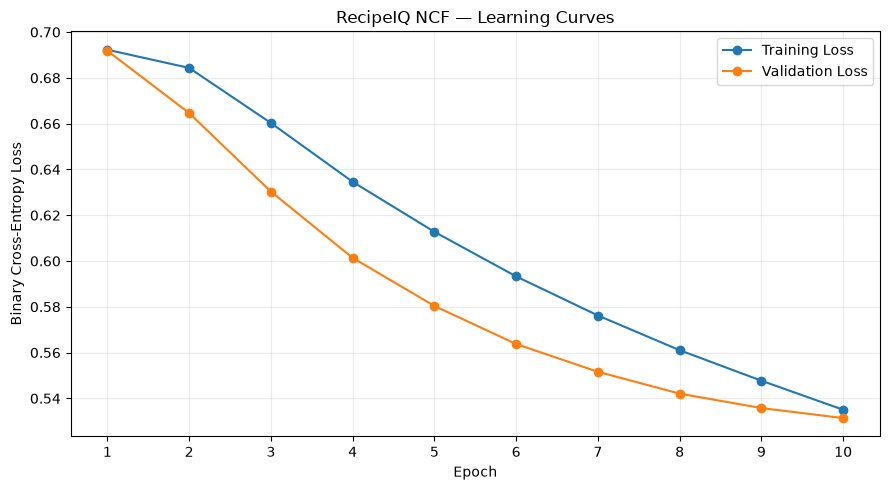

In [32]:
plt.figure(figsize=(9, 5))

plt.plot(range(1, len(train_losses) + 1),
         train_losses, marker="o", label="Training Loss")

plt.plot(range(1, len(val_losses) + 1),
         val_losses, marker="o", label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Binary Cross-Entropy Loss")
plt.title("RecipeIQ NCF — Learning Curves")
plt.xticks(range(1, len(train_losses) + 1))
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## Step 6

In [33]:
import numpy as np
import pandas as pd
import torch

model.eval()

with torch.no_grad():
    val_scores = model(
        val_users.to(device),
        val_recipes.to(device)
    ).squeeze().cpu().numpy()

val_eval = pd.DataFrame({
    "user": val_users.cpu().numpy(),
    "recipe": val_recipes.cpu().numpy(),
    "label": val_labels.cpu().numpy(),
    "score": val_scores
})

print("Validation predictions:", val_eval.shape)
print("Missing scores:", val_eval["score"].isna().sum())
print("Unique users:", val_eval["user"].nunique())
print("Label counts:")
print(val_eval["label"].value_counts().sort_index())

display(val_eval.head())

Validation predictions: (124256, 4)
Missing scores: 0
Unique users: 18182
Label counts:
label
0.0    62128
1.0    62128
Name: count, dtype: int64


,user,recipe,label,score
0,25,111814,0.0,-1.535270
1,234,15439,1.0,0.671477
2,369,28483,1.0,2.095258
3,259,38431,0.0,-2.665989
4,937,110867,0.0,-0.801637


In [34]:
import numpy as np
import pandas as pd

K = 10

def evaluate_ranking(group, k=10):
    # Sort each user's candidate recipes by predicted score
    group = group.sort_values("score", ascending=False)

    labels = group["label"].to_numpy()
    top_labels = labels[:k]

    # Number of relevant recipes in the top K
    hits = top_labels.sum()

    # Precision@K and Recall@K
    precision = hits / k
    total_relevant = labels.sum()
    recall = hits / total_relevant if total_relevant > 0 else 0.0

    # NDCG@K
    discounts = 1 / np.log2(np.arange(2, len(top_labels) + 2))
    dcg = np.sum(top_labels * discounts)

    ideal_labels = np.sort(labels)[::-1][:k]
    ideal_discounts = 1 / np.log2(
        np.arange(2, len(ideal_labels) + 2)
    )
    idcg = np.sum(ideal_labels * ideal_discounts)

    ndcg = dcg / idcg if idcg > 0 else 0.0

    # Hit Rate@K: at least one relevant recipe in top K
    hit_rate = float(hits > 0)

    return pd.Series({
        "Precision@10": precision,
        "Recall@10": recall,
        "NDCG@10": ndcg,
        "Hit Rate@10": hit_rate
    })

In [35]:
# Evaluate each user separately, then average across users
user_metrics = (
    val_eval.groupby("user", sort=False)
    .apply(evaluate_ranking, k=K)
)

C:\Users\Mastm\AppData\Local\Temp\ipykernel_14908\1444536833.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(evaluate_ranking, k=K)


In [36]:
# Summary metrics
ncf_validation_metrics = user_metrics.mean()

print("========== RECIPEIQ NCF: VALIDATION RESULTS ==========")
print("Users evaluated:", len(user_metrics))
print(ncf_validation_metrics.round(4))

print("\nMetric interpretation:")
print("Precision@10: Relevant candidates in the top 10 / 10")
print("Recall@10: Relevant candidates retrieved / all relevant candidates")
print("NDCG@10: Rewards relevant recipes ranked nearer the top")
print("Hit Rate@10: Fraction of users with at least one relevant top-10 recipe")

========== RECIPEIQ NCF: VALIDATION RESULTS ==========
Users evaluated: 18182
Precision@10    0.2113
Recall@10       0.9646
NDCG@10         0.9386
Hit Rate@10     1.0000
dtype: float64

Metric interpretation:
Precision@10: Relevant candidates in the top 10 / 10
Recall@10: Relevant candidates retrieved / all relevant candidates
NDCG@10: Rewards relevant recipes ranked nearer the top
Hit Rate@10: Fraction of users with at least one relevant top-10 recipe


### temporary audit

In [37]:
# Count the number of candidates and positives for each user
candidate_audit = (
    val_eval.groupby("user")
    .agg(
        total_candidates=("recipe", "size"),
        positive_candidates=("label", "sum"),
        negative_candidates=("label", lambda x: (x == 0).sum())
    )
)

print("========== CANDIDATE SET AUDIT ==========")

print("\nCandidates per user:")
print(
    candidate_audit["total_candidates"]
    .describe(percentiles=[0.25, 0.50, 0.75, 0.90, 0.95])
)

print("\nUsers with fewer than 10 candidates:",
      (candidate_audit["total_candidates"] < 10).sum())

print("Users with at least 10 candidates:",
      (candidate_audit["total_candidates"] >= 10).sum())

print("\nPositive candidates per user:")
print(candidate_audit["positive_candidates"].describe())

print("\nUsers with no positive candidates:",
      (candidate_audit["positive_candidates"] == 0).sum())

print("\nUsers with fewer than 10 candidates (%):",
      round(
          (candidate_audit["total_candidates"] < 10).mean() * 100,
          2
      ))

========== CANDIDATE SET AUDIT ==========

Candidates per user:
count    18182.000000
mean         6.834012
std         22.006606
min          2.000000
25%          2.000000
50%          2.000000
75%          4.000000
90%         10.000000
95%         22.000000
max        774.000000
Name: total_candidates, dtype: float64

Users with fewer than 10 candidates: 15974
Users with at least 10 candidates: 2208

Positive candidates per user:
count    18182.000000
mean         3.417006
std         11.000875
min          1.000000
25%          1.000000
50%          1.000000
75%          2.000000
max        387.000000
Name: positive_candidates, dtype: float64

Users with no positive candidates: 0

Users with fewer than 10 candidates (%): 87.86


In [38]:
# Audit positive and negative candidates per user

per_user_labels = (
    val_eval.groupby("user")["label"]
    .agg(
        positive_count=lambda x: (x == 1).sum(),
        negative_count=lambda x: (x == 0).sum(),
        total_candidates="size"
    )
)

print("========== NEGATIVE SAMPLING AUDIT ==========")

print(
    "Users with equal positive and negative counts:",
    (
        per_user_labels["positive_count"]
        == per_user_labels["negative_count"]
    ).sum()
)

print(
    "Users with more positives than negatives:",
    (
        per_user_labels["positive_count"]
        > per_user_labels["negative_count"]
    ).sum()
)

print(
    "Users with more negatives than positives:",
    (
        per_user_labels["negative_count"]
        > per_user_labels["positive_count"]
    ).sum()
)

print("\nPositive-to-negative count ratio:")
print(
    (
        per_user_labels["negative_count"]
        / per_user_labels["positive_count"].clip(lower=1)
    ).describe()
)

display(per_user_labels.head(10))

========== NEGATIVE SAMPLING AUDIT ==========
Users with equal positive and negative counts: 18182
Users with more positives than negatives: 0
Users with more negatives than positives: 0

Positive-to-negative count ratio:
count    18182.0
mean         1.0
std          0.0
min          1.0
25%          1.0
50%          1.0
75%          1.0
max          1.0
dtype: float64


,positive_count,negative_count,total_candidates
user,,,
0,3,3,6
1,3,3,6
2,2,2,4
3,137,137,274
4,32,32,64
5,22,22,44
6,1,1,2
8,19,19,38
10,69,69,138


In [39]:
SEED = 42
NEGATIVES_PER_USER = 99

rng = np.random.default_rng(SEED)

# Find recipes with positive training history
train_positive_items = set(
    positive_train["i"].unique()
)

In [40]:
# Keep validation positives whose recipes appeared
#    positively in training, and whose users have training history
train_users = set(positive_train["u"].unique())

val_positive_targets = (
    validation_custom.loc[
        (validation_custom["label"] == 1)
        & (validation_custom["i"].isin(train_positive_items))
        & (validation_custom["u"].isin(train_users)),
        ["u", "i"]
    ]
    .drop_duplicates()
    .rename(columns={"u": "user", "i": "recipe"})
)


In [41]:
# Prepare the full processed recipe catalog
catalog = np.asarray(catalog_items, dtype=np.int64)

In [42]:
# Sample 99 unseen negative recipes per eligible user
negative_rows = []

for user, group in val_positive_targets.groupby("user"):
    known_items = known_items_by_user.get(user, set())

    # Exclude all recipes already interacted with by this user
    available_items = np.setdiff1d(
        catalog,
        np.fromiter(known_items, dtype=np.int64),
        assume_unique=False
    )

    if len(available_items) < NEGATIVES_PER_USER:
        raise ValueError(
            f"User {user} has only {len(available_items)} "
            "available negative candidates."
        )

    sampled_items = rng.choice(
        available_items,
        size=NEGATIVES_PER_USER,
        replace=False
    )

    negative_rows.extend(
        (user, item, 0) for item in sampled_items
    )

In [43]:
# Combine positive and negative candidates
val_positive_candidates = val_positive_targets.copy()
val_positive_candidates["label"] = 1

val_negative_candidates = pd.DataFrame(
    negative_rows,
    columns=["user", "recipe", "label"]
)

val_candidates = pd.concat(
    [val_positive_candidates, val_negative_candidates],
    ignore_index=True
)

In [44]:
# Verify the candidate set
print("Positive candidates:", len(val_positive_candidates))
print("Negative candidates:", len(val_negative_candidates))
print("Total candidates:", len(val_candidates))
print("Unique users:", val_candidates["user"].nunique())

print(
    "\nDuplicate user-recipe pairs:",
    val_candidates.duplicated(["user", "recipe"]).sum()
)

print("\nCandidates per user:")
print(
    val_candidates.groupby("user").size()
    .describe(percentiles=[0.25, 0.50, 0.75, 0.90])
)

print("\nLabel distribution:")
print(val_candidates["label"].value_counts().sort_index())

Positive candidates: 62128
Negative candidates: 1800018
Total candidates: 1862146
Unique users: 18182

Duplicate user-recipe pairs: 0

Candidates per user:
count    18182.000000
mean       102.417006
std         11.003303
min        100.000000
25%        100.000000
50%        100.000000
75%        101.000000
90%        104.000000
max        486.000000
dtype: float64

Label distribution:
label
0    1800018
1      62128
Name: count, dtype: int64


In [45]:
# STEP 6E: Score the validation candidates

import torch
import numpy as np
import pandas as pd

model.eval()

candidate_users = val_candidates["user"].to_numpy(dtype=np.int64)
candidate_recipes = val_candidates["recipe"].to_numpy(dtype=np.int64)

all_scores = []
BATCH_SIZE_EVAL = 65536

with torch.no_grad():
    for start in range(0, len(val_candidates), BATCH_SIZE_EVAL):
        end = min(start + BATCH_SIZE_EVAL, len(val_candidates))

        users_batch = torch.as_tensor(
            candidate_users[start:end],
            dtype=torch.long,
            device=device
        )

        recipes_batch = torch.as_tensor(
            candidate_recipes[start:end],
            dtype=torch.long,
            device=device
        )

        scores_batch = model(users_batch, recipes_batch)

        all_scores.append(scores_batch.cpu().numpy())

val_candidates_scored = val_candidates.copy()
val_candidates_scored["score"] = np.concatenate(all_scores)

print("Scored candidate shape:", val_candidates_scored.shape)
print("Missing scores:", val_candidates_scored["score"].isna().sum())
print(
    "All scores finite:",
    np.isfinite(val_candidates_scored["score"]).all()
)

display(val_candidates_scored.head())

Scored candidate shape: (1862146, 4)
Missing scores: 0
All scores finite: True


,user,recipe,label,score
0,22095,87844,1,-1.109174
1,24732,138181,1,0.016856
2,1674,133364,1,1.579669
3,1674,130720,1,-0.343437
4,1674,63463,1,1.627707


In [46]:
# STEP 6F: Calculate ranking metrics at K=10

K = 10

def ranking_metrics_at_k(group, k=10):
    group = group.sort_values("score", ascending=False)

    labels = group["label"].to_numpy(dtype=float)
    top_labels = labels[:k]

    hits = top_labels.sum()
    total_relevant = labels.sum()

    precision = hits / k
    recall = hits / total_relevant if total_relevant > 0 else 0.0

    discounts = 1 / np.log2(np.arange(2, len(top_labels) + 2))
    dcg = np.sum(top_labels * discounts)

    ideal_labels = np.sort(labels)[::-1][:k]
    ideal_discounts = 1 / np.log2(
        np.arange(2, len(ideal_labels) + 2)
    )
    idcg = np.sum(ideal_labels * ideal_discounts)

    ndcg = dcg / idcg if idcg > 0 else 0.0
    hit_rate = float(hits > 0)

    return pd.Series({
        "Precision@10": precision,
        "Recall@10": recall,
        "NDCG@10": ndcg,
        "Hit Rate@10": hit_rate
    })

user_metrics_99 = (
    val_candidates_scored.groupby("user", sort=False)
    .apply(ranking_metrics_at_k, k=K)
)

ncf_validation_metrics_99 = user_metrics_99.mean()

print("========== RECIPEIQ NCF: 99-NEGATIVE VALIDATION ==========")
print("Users evaluated:", len(user_metrics_99))
print(ncf_validation_metrics_99.round(4))

========== RECIPEIQ NCF: 99-NEGATIVE VALIDATION ==========
Users evaluated: 18182
Precision@10    0.1288
Recall@10       0.5841
NDCG@10         0.4290
Hit Rate@10     0.7245
dtype: float64


C:\Users\Mastm\AppData\Local\Temp\ipykernel_14908\1820426337.py:38: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(ranking_metrics_at_k, k=K)


### Temporary Audits

In [47]:
import pandas as pd
import numpy as np

# 1. Check dataframe shapes and columns
print("========== DATAFRAME AUDIT ==========")

for name, df in [
    ("positive_train", positive_train),
    ("validation_custom", validation_custom),
    ("ncf_train", ncf_train),
    ("val_candidates", val_candidates)
]:
    print(f"\n{name}")
    print("Shape:", df.shape)
    print("Columns:", df.columns.tolist())
    print("Missing values:", df.isna().sum().sum())

# 2. Check duplicate user-recipe pairs
print("\n========== DUPLICATE PAIRS ==========")

for name, df in [
    ("positive_train", positive_train),
    ("validation_custom", validation_custom),
    ("ncf_train", ncf_train),
    ("val_candidates", val_candidates)
]:
    if {"user", "recipe"}.issubset(df.columns):
        pair_cols = ["user", "recipe"]
    elif {"u", "i"}.issubset(df.columns):
        pair_cols = ["u", "i"]
    elif {"user_id", "recipe_id"}.issubset(df.columns):
        pair_cols = ["user_id", "recipe_id"]
    else:
        print(f"{name}: No recognized user/recipe columns")
        continue

    print(
        f"{name}:",
        df.duplicated(pair_cols).sum(),
        "duplicate pairs"
    )

========== DATAFRAME AUDIT ==========

positive_train
Shape: (520611, 2)
Columns: ['u', 'i']
Missing values: 0

validation_custom
Shape: (79368, 7)
Columns: ['user_id', 'recipe_id', 'date', 'rating', 'u', 'i', 'label']
Missing values: 0

ncf_train
Shape: (1084804, 3)
Columns: ['u', 'i', 'label']
Missing values: 0

val_candidates
Shape: (1862146, 3)
Columns: ['user', 'recipe', 'label']
Missing values: 0

========== DUPLICATE PAIRS ==========
positive_train: 0 duplicate pairs
validation_custom: 0 duplicate pairs
ncf_train: 0 duplicate pairs
val_candidates: 0 duplicate pairs


In [48]:
print("========== KNOWN ITEMS AUDIT ==========")

print("Users in known_items_by_user:", len(known_items_by_user))

sample_users = list(known_items_by_user.keys())[:5]

for user in sample_users:
    items = known_items_by_user[user]
    print(
        f"User {user}:",
        "known items =", len(items),
        "container type =", type(items).__name__
    )

print("\n========== NEGATIVE LABEL AUDIT ==========")

# Separate positive and negative candidate pairs
val_pos = val_candidates.loc[
    val_candidates["label"] == 1, ["user", "recipe"]
].copy()

val_neg = val_candidates.loc[
    val_candidates["label"] == 0, ["user", "recipe"]
].copy()

# Check whether a negative candidate is actually in the
# user's known-item exclusion set.
negative_is_known = [
    recipe in known_items_by_user.get(user, set())
    for user, recipe in zip(val_neg["user"], val_neg["recipe"])
]

print("Negative candidates:", len(val_neg))
print("Negatives found in known-item sets:", sum(negative_is_known))

# Check for any user-recipe pair assigned both labels
pos_pairs = set(map(tuple, val_pos[["user", "recipe"]].to_numpy()))
neg_pairs = set(map(tuple, val_neg[["user", "recipe"]].to_numpy()))

print("Pairs labelled both positive and negative:", len(pos_pairs & neg_pairs))

========== KNOWN ITEMS AUDIT ==========
Users in known_items_by_user: 25076
User 0: known items = 31 container type = set
User 1: known items = 39 container type = set
User 2: known items = 28 container type = set
User 3: known items = 1513 container type = set
User 4: known items = 376 container type = set

========== NEGATIVE LABEL AUDIT ==========
Negative candidates: 1800018
Negatives found in known-item sets: 0
Pairs labelled both positive and negative: 0


In [49]:
print("========== SOURCE DATAFRAMES ==========")

for name in [
    "interactions_train",
    "interactions_validation",
    "interactions_test",
    "positive_train",
    "validation_custom"
]:
    df = globals().get(name)

    if df is not None:
        print(f"\n{name}: shape={df.shape}")
        print("Columns:", df.columns.tolist())

========== SOURCE DATAFRAMES ==========

positive_train: shape=(520611, 2)
Columns: ['u', 'i']

validation_custom: shape=(79368, 7)
Columns: ['user_id', 'recipe_id', 'date', 'rating', 'u', 'i', 'label']


In [50]:
print("========== CANDIDATE DISTRIBUTION ==========")

candidate_counts = (
    val_candidates
    .groupby("user")
    .agg(
        total_candidates=("recipe", "size"),
        positives=("label", "sum"),
        negatives=("label", lambda x: (x == 0).sum()),
        unique_recipes=("recipe", "nunique")
    )
)

print("\nCandidate counts:")
print(candidate_counts.describe().round(3))

print("\nUsers with fewer than 10 candidates:",
      (candidate_counts["total_candidates"] < 10).sum())

print("\nUsers with zero positives:",
      (candidate_counts["positives"] == 0).sum())

print("\nUsers with zero negatives:",
      (candidate_counts["negatives"] == 0).sum())

print("\nTop 10 users by number of positive targets:")
print(
    candidate_counts
    .sort_values("positives", ascending=False)
    .head(10)
)

print("\nLabel values:", sorted(val_candidates["label"].unique()))
print("Labels outside 0/1:",
      (~val_candidates["label"].isin([0, 1])).sum())

========== CANDIDATE DISTRIBUTION ==========

Candidate counts:
       total_candidates  positives  negatives  unique_recipes
count         18182.000  18182.000    18182.0       18182.000
mean            102.417      3.417       99.0         102.417
std              11.003     11.003        0.0          11.003
min             100.000      1.000       99.0         100.000
25%             100.000      1.000       99.0         100.000
50%             100.000      1.000       99.0         100.000
75%             101.000      2.000       99.0         101.000
max             486.000    387.000       99.0         486.000

Users with fewer than 10 candidates: 0

Users with zero positives: 0

Users with zero negatives: 0

Top 10 users by number of positive targets:
      total_candidates  positives  negatives  unique_recipes
user                                                        
94                 486        387         99             486
275                463        364         99      

In [51]:
K = 10

def audit_ranking_metrics(group, k=10):
    group = group.sort_values("score", ascending=False)

    labels = group["label"].to_numpy(dtype=float)
    top_labels = labels[:k]

    hits = top_labels.sum()
    total_relevant = labels.sum()

    precision = hits / k
    recall = hits / total_relevant if total_relevant > 0 else 0.0

    discounts = 1 / np.log2(np.arange(2, len(top_labels) + 2))
    dcg = np.sum(top_labels * discounts)

    ideal_labels = np.sort(labels)[::-1][:k]
    ideal_discounts = 1 / np.log2(
        np.arange(2, len(ideal_labels) + 2)
    )
    idcg = np.sum(ideal_labels * ideal_discounts)

    ndcg = dcg / idcg if idcg > 0 else 0.0
    hit_rate = float(hits > 0)

    return pd.Series({
        "Precision@10": precision,
        "Recall@10": recall,
        "NDCG@10": ndcg,
        "Hit Rate@10": hit_rate
    })

audit_metrics = (
    val_candidates_scored
    .groupby("user", sort=False)
    .apply(audit_ranking_metrics, k=K)
)

print("Users evaluated:", len(audit_metrics))
print("\nRecomputed metrics:")
print(audit_metrics.mean().round(4))

print("\nNon-finite metric values:")
print((~np.isfinite(audit_metrics)).sum())

Users evaluated: 18182

Recomputed metrics:
Precision@10    0.1288
Recall@10       0.5841
NDCG@10         0.4290
Hit Rate@10     0.7245
dtype: float64

Non-finite metric values:
Precision@10    0
Recall@10       0
NDCG@10         0
Hit Rate@10     0
dtype: int64


C:\Users\Mastm\AppData\Local\Temp\ipykernel_14908\3373404642.py:37: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(audit_ranking_metrics, k=K)


In [52]:
# Convert training positives to (user, recipe) pairs.
train_pairs = set(
    zip(
        positive_train["u"].astype(int),
        positive_train["i"].astype(int)
    )
)

# Validation positives, using the processed IDs u and i.
val_positive_df = validation_custom[
    validation_custom["label"] == 1
]

val_positive_pairs = set(
    zip(
        val_positive_df["u"].astype(int),
        val_positive_df["i"].astype(int)
    )
)

# Positive candidate pairs from the evaluation set.
candidate_positive_pairs = set(
    zip(
        val_candidates.loc[
            val_candidates["label"] == 1, "user"
        ].astype(int),
        val_candidates.loc[
            val_candidates["label"] == 1, "recipe"
        ].astype(int)
    )
)

# 1. Training-validation overlap
print("\n1. Train/validation positive overlap:")
print("Overlapping pairs:", len(train_pairs & val_positive_pairs))

# 2. Verify positive candidate construction
print("\n2. Validation target consistency:")
print("Validation positive pairs:", len(val_positive_pairs))
print("Candidate positive pairs:", len(candidate_positive_pairs))
print(
    "Validation positives missing from candidates:",
    len(val_positive_pairs - candidate_positive_pairs)
)
print(
    "Unexpected candidate positives:",
    len(candidate_positive_pairs - val_positive_pairs)
)

# 3. Check IDs against embedding table ranges
print("\n3. Embedding ID ranges:")
print("n_users:", n_users)
print("n_recipes:", n_recipes)

for name, df, user_col, recipe_col in [
    ("positive_train", positive_train, "u", "i"),
    ("validation_custom", validation_custom, "u", "i"),
    ("val_candidates", val_candidates, "user", "recipe")
]:
    invalid_users = (
        (df[user_col] < 0) | (df[user_col] >= n_users)
    ).sum()

    invalid_recipes = (
        (df[recipe_col] < 0) | (df[recipe_col] >= n_recipes)
    ).sum()

    print(
        f"{name}: invalid user IDs={invalid_users}, "
        f"invalid recipe IDs={invalid_recipes}"
    )

# 4. Confirm the exclusion set covers all training positives
print("\n4. Training-positive exclusion coverage:")

missing_from_known = sum(
    recipe not in known_items_by_user.get(user, set())
    for user, recipe in train_pairs
)

print("Training positive pairs:", len(train_pairs))
print("Missing from known-item sets:", missing_from_known)

# 5. Confirm validation targets are not accidentally treated as negatives
print("\n5. Validation-positive versus negative candidates:")

negative_pairs = set(
    zip(
        val_candidates.loc[
            val_candidates["label"] == 0, "user"
        ].astype(int),
        val_candidates.loc[
            val_candidates["label"] == 0, "recipe"
        ].astype(int)
    )
)

print(
    "Validation positives appearing as negatives:",
    len(val_positive_pairs & negative_pairs)
)


1. Train/validation positive overlap:
Overlapping pairs: 0

2. Validation target consistency:
Validation positive pairs: 72774
Candidate positive pairs: 62128
Validation positives missing from candidates: 10646
Unexpected candidate positives: 0

3. Embedding ID ranges:
n_users: 25076
n_recipes: 178265
positive_train: invalid user IDs=0, invalid recipe IDs=0
validation_custom: invalid user IDs=0, invalid recipe IDs=0
val_candidates: invalid user IDs=0, invalid recipe IDs=0

4. Training-positive exclusion coverage:
Training positive pairs: 520611
Missing from known-item sets: 0

5. Validation-positive versus negative candidates:
Validation positives appearing as negatives: 0


In [53]:
# All positive validation targets
val_pos_all = validation_custom[
    validation_custom["label"] == 1
].copy()

# Users and recipes present in positive training interactions
train_users = set(positive_train["u"].astype(int).unique())
train_recipes = set(positive_train["i"].astype(int).unique())

# Warm-start eligibility
user_seen = val_pos_all["u"].astype(int).isin(train_users)
recipe_seen = val_pos_all["i"].astype(int).isin(train_recipes)

val_pos_all["user_seen_in_train"] = user_seen
val_pos_all["recipe_seen_in_train"] = recipe_seen

val_pos_all["eligibility"] = np.select(
    [
        user_seen & recipe_seen,
        ~user_seen & recipe_seen,
        user_seen & ~recipe_seen,
        ~user_seen & ~recipe_seen
    ],
    [
        "Eligible: user and recipe seen",
        "Excluded: user unseen",
        "Excluded: recipe unseen",
        "Excluded: both unseen"
    ],
    default="Unknown"
)

print("\nTarget counts by eligibility:")
print(val_pos_all["eligibility"].value_counts())

print("\nTotal positive validation targets:", len(val_pos_all))
print("Eligible warm-start targets:", (user_seen & recipe_seen).sum())
print("Ineligible targets:", (~(user_seen & recipe_seen)).sum())

# Verify that the eligibility rule explains the candidate count
candidate_pairs = set(
    zip(
        val_candidates.loc[
            val_candidates["label"] == 1, "user"
        ].astype(int),
        val_candidates.loc[
            val_candidates["label"] == 1, "recipe"
        ].astype(int)
    )
)

eligible_pairs = set(
    zip(
        val_pos_all.loc[user_seen & recipe_seen, "u"].astype(int),
        val_pos_all.loc[user_seen & recipe_seen, "i"].astype(int)
    )
)

print("\n========== CONSISTENCY CHECK ==========")
print("Eligible target pairs:", len(eligible_pairs))
print("Candidate positive pairs:", len(candidate_pairs))
print("Eligible targets missing from candidates:",
      len(eligible_pairs - candidate_pairs))
print("Candidate positives not eligible:",
      len(candidate_pairs - eligible_pairs))


Target counts by eligibility:
eligibility
Eligible: user and recipe seen    62128
Excluded: recipe unseen           10279
Excluded: user unseen               336
Excluded: both unseen                31
Name: count, dtype: int64

Total positive validation targets: 72774
Eligible warm-start targets: 62128
Ineligible targets: 10646

========== CONSISTENCY CHECK ==========
Eligible target pairs: 62128
Candidate positive pairs: 62128
Eligible targets missing from candidates: 0
Candidate positives not eligible: 0


In [54]:
# 1. Combine your existing interaction splits
official_splits = [train_raw, val_raw, test_raw]

all_interactions = pd.concat(
    [df[["u", "i"]] for df in official_splits],
    ignore_index=True
).drop_duplicates()

all_interaction_pairs = set(
    zip(
        all_interactions["u"].astype(int),
        all_interactions["i"].astype(int)
    )
)

print("Unique known interaction pairs:", len(all_interaction_pairs))

# 2. Extract validation negative pairs
negative_pairs = set(
    zip(
        val_candidates.loc[
            val_candidates["label"] == 0, "user"
        ].astype(int),
        val_candidates.loc[
            val_candidates["label"] == 0, "recipe"
        ].astype(int)
    )
)

print("Unique validation negative pairs:", len(negative_pairs))

# 3. Check overlap
overlap = negative_pairs & all_interaction_pairs

print("Negatives found in official interaction data:", len(overlap))

if overlap:
    print("Examples of overlapping pairs:", list(overlap)[:10])
else:
    print("PASS: No sampled negatives overlap with known interactions.")

# 4. Check source consistency
source_pairs = set(
    zip(
        all_known_pairs["u"].astype(int),
        all_known_pairs["i"].astype(int)
    )
)

print("\n========== SOURCE CONSISTENCY ==========")
print("Interactions missing from all_known_pairs:",
      len(all_interaction_pairs - source_pairs))
print("Unexpected pairs in all_known_pairs:",
      len(source_pairs - all_interaction_pairs))

Unique known interaction pairs: 718379
Unique validation negative pairs: 1800018
Negatives found in official interaction data: 0
PASS: No sampled negatives overlap with known interactions.

========== SOURCE CONSISTENCY ==========
Interactions missing from all_known_pairs: 0
Unexpected pairs in all_known_pairs: 0


In [55]:
print("========== AVAILABLE DATAFRAMES ==========")

for name, obj in list(globals().items()):
    if isinstance(obj, pd.DataFrame):
        print(f"\nVariable: {name}")
        print("Shape:", obj.shape)
        print("Columns:", obj.columns.tolist())

========== AVAILABLE DATAFRAMES ==========

Variable: train_raw
Shape: (698901, 6)
Columns: ['user_id', 'recipe_id', 'date', 'rating', 'u', 'i']

Variable: val_raw
Shape: (7023, 6)
Columns: ['user_id', 'recipe_id', 'date', 'rating', 'u', 'i']

Variable: test_raw
Shape: (12455, 6)
Columns: ['user_id', 'recipe_id', 'date', 'rating', 'u', 'i']

Variable: all_interactions
Shape: (718379, 2)
Columns: ['u', 'i']

Variable: interactions
Shape: (718379, 7)
Columns: ['user_id', 'recipe_id', 'date', 'rating', 'u', 'i', 'label']

Variable: group
Shape: (1, 2)
Columns: ['user', 'recipe']

Variable: train_custom
Shape: (564193, 7)
Columns: ['user_id', 'recipe_id', 'date', 'rating', 'u', 'i', 'label']

Variable: validation_custom
Shape: (79368, 7)
Columns: ['user_id', 'recipe_id', 'date', 'rating', 'u', 'i', 'label']

Variable: test_custom
Shape: (74818, 7)
Columns: ['user_id', 'recipe_id', 'date', 'rating', 'u', 'i', 'label']

Variable: df
Shape: (1862146, 3)
Columns: ['user', 'recipe', 'label']

V

In [56]:
# 1. Confirm the source interaction pairs
known_pairs = set(
    zip(
        all_known_pairs["u"].astype(int),
        all_known_pairs["i"].astype(int)
    )
)

print("Known interaction pairs:", len(known_pairs))

# 2. Extract the sampled validation negatives
negative_pairs = set(
    zip(
        val_candidates.loc[
            val_candidates["label"] == 0, "user"
        ].astype(int),
        val_candidates.loc[
            val_candidates["label"] == 0, "recipe"
        ].astype(int)
    )
)

print("Unique validation negative pairs:", len(negative_pairs))

# 3. Find negatives that are actually observed interactions
overlap = negative_pairs & known_pairs

print(
    "Negatives that appear in known interactions:",
    len(overlap)
)

if overlap:
    print("Examples:", list(overlap)[:10])
else:
    print("PASS: No validation negatives overlap with known interactions.")

# 4. Check whether the stored all_known_pairs matches all_interactions
source_pairs = set(
    zip(
        all_interactions["u"].astype(int),
        all_interactions["i"].astype(int)
    )
)

print("\n========== SOURCE CONSISTENCY ==========")
print("Interactions missing from all_known_pairs:",
      len(source_pairs - known_pairs))
print("Unexpected pairs in all_known_pairs:",
      len(known_pairs - source_pairs))

Known interaction pairs: 718379
Unique validation negative pairs: 1800018
Negatives that appear in known interactions: 0
PASS: No validation negatives overlap with known interactions.

========== SOURCE CONSISTENCY ==========
Interactions missing from all_known_pairs: 0
Unexpected pairs in all_known_pairs: 0


In [57]:
# Reconstruct the expected exclusion set from all known interactions.
expected_known_items = (
    all_known_pairs
    .groupby("u")["i"]
    .apply(set)
    .to_dict()
)

print("Users in expected exclusion set:", len(expected_known_items))
print("Users in actual exclusion set:", len(known_items_by_user))

# Compare the actual and expected sets for each user.
all_users = set(expected_known_items) | set(known_items_by_user)

missing_items = 0
extra_items = 0
users_with_mismatch = 0

for user in all_users:
    expected = expected_known_items.get(user, set())
    actual = known_items_by_user.get(user, set())

    missing_items += len(expected - actual)
    extra_items += len(actual - expected)

    if expected != actual:
        users_with_mismatch += 1

print("Users with mismatched exclusion sets:", users_with_mismatch)
print("Known items missing from actual sets:", missing_items)
print("Extra items in actual sets:", extra_items)

Users in expected exclusion set: 25076
Users in actual exclusion set: 25076
Users with mismatched exclusion sets: 0
Known items missing from actual sets: 0
Extra items in actual sets: 0


## Step 10

In [58]:
# Count positive training interactions for each recipe.
recipe_popularity = (
    positive_train
    .groupby("i")
    .size()
    .rename("popularity")
    .reset_index()
    .rename(columns={"i": "recipe"})
)

print("Recipes with positive training interactions:",
      len(recipe_popularity))

print("\nPopularity distribution:")
print(recipe_popularity["popularity"].describe().round(3))

print("\nTop 10 most popular recipes:")
print(
    recipe_popularity
    .sort_values("popularity", ascending=False)
    .head(10)
    .to_string(index=False)
)

# Add popularity scores to the existing validation candidates.
# Recipes without positive training interactions receive a score of 0.
popularity_candidates = val_candidates.merge(
    recipe_popularity,
    on="recipe",
    how="left",
    validate="many_to_one"
)

popularity_candidates["popularity"] = (
    popularity_candidates["popularity"].fillna(0)
)

print("\nPopularity candidate shape:",
      popularity_candidates.shape)

print("Missing popularity scores:",
      popularity_candidates["popularity"].isna().sum())

Recipes with positive training interactions: 149952

Popularity distribution:
count    149952.000
mean          3.472
std           9.853
min           1.000
25%           1.000
50%           2.000
75%           3.000
max         726.000
Name: popularity, dtype: float64

Top 10 most popular recipes:
 recipe  popularity
  99787         726
 134610         676
 117899         654
 135961         632
 147374         593
 101819         522
  52334         503
 127080         487
 147180         467
  55772         461

Popularity candidate shape: (1862146, 4)
Missing popularity scores: 0


In [59]:
K = 10
seeds = [21, 42, 123, 2026, 7]

def calculate_ranking_metrics(group, k=10):
    group = group.sort_values("score", ascending=False)

    labels = group["label"].to_numpy(dtype=float)
    top_labels = labels[:k]

    hits = top_labels.sum()
    total_relevant = labels.sum()

    precision = hits / k
    recall = hits / total_relevant if total_relevant > 0 else 0.0

    discounts = 1 / np.log2(np.arange(2, len(top_labels) + 2))
    dcg = np.sum(top_labels * discounts)

    ideal_labels = np.sort(labels)[::-1][:k]
    ideal_discounts = 1 / np.log2(
        np.arange(2, len(ideal_labels) + 2)
    )
    idcg = np.sum(ideal_labels * ideal_discounts)

    ndcg = dcg / idcg if idcg > 0 else 0.0

    return pd.Series({
        "Precision@10": precision,
        "Recall@10": recall,
        "NDCG@10": ndcg,
        "Hit Rate@10": float(hits > 0)
    })


results = []

for seed in seeds:
    rng = np.random.default_rng(seed)

    # Random tie-breaker smaller than 1, so it cannot
    # reverse the order of different integer popularity scores.
    scored = popularity_candidates[
        ["user", "recipe", "label", "popularity"]
    ].copy()

    scored["score"] = (
        scored["popularity"].to_numpy(dtype=float)
        + rng.random(len(scored)) * 1e-6
    )

    user_metrics_pop = (
        scored.groupby("user", sort=False)
        .apply(calculate_ranking_metrics, k=K)
    )

    results.append(user_metrics_pop.mean().rename(f"seed_{seed}"))

results_df = pd.DataFrame(results)

print("\nMetrics by random tie-breaking seed:")
print(results_df.round(4).to_string())

print("\n========== POPULARITY BASELINE SUMMARY ==========")
print("Mean across seeds:")
print(results_df.mean().round(4))

print("\nStandard deviation across seeds:")
print(results_df.std().round(4))

print("\nUsers evaluated:", popularity_candidates["user"].nunique())

C:\Users\Mastm\AppData\Local\Temp\ipykernel_14908\6189262.py:53: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(calculate_ranking_metrics, k=K)
C:\Users\Mastm\AppData\Local\Temp\ipykernel_14908\6189262.py:53: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(calculate_ranking_metrics, k=K)
C:\Users\Mastm\AppData\Local\Temp\ipykernel_14908\6189262.py:53: DeprecationWarning: DataFrameGroupBy.apply op


Metrics by random tie-breaking seed:
           Precision@10  Recall@10  NDCG@10  Hit Rate@10
seed_21          0.1490     0.6735   0.5526       0.7961
seed_42          0.1489     0.6731   0.5525       0.7955
seed_123         0.1489     0.6727   0.5526       0.7950
seed_2026        0.1489     0.6734   0.5527       0.7960
seed_7           0.1489     0.6734   0.5525       0.7961

========== POPULARITY BASELINE SUMMARY ==========
Mean across seeds:
Precision@10    0.1489
Recall@10       0.6732
NDCG@10         0.5526
Hit Rate@10     0.7957
dtype: float64

Standard deviation across seeds:
Precision@10    0.0000
Recall@10       0.0003
NDCG@10         0.0001
Hit Rate@10     0.0005
dtype: float64

Users evaluated: 18182


C:\Users\Mastm\AppData\Local\Temp\ipykernel_14908\6189262.py:53: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(calculate_ranking_metrics, k=K)


In [60]:
import numpy as np
import pandas as pd

required_vars = [
    "positive_train",
    "val_candidates",
    "val_candidates_scored",
    "popularity_candidates"
]

for name in required_vars:
    if name in globals():
        print(f"PASS: {name} exists — shape: {globals()[name].shape}")
    else:
        print(f"MISSING: {name}")

PASS: positive_train exists — shape: (520611, 2)
PASS: val_candidates exists — shape: (1862146, 3)
PASS: val_candidates_scored exists — shape: (1862146, 4)
PASS: popularity_candidates exists — shape: (1862146, 4)


### Temporary Audits

In [61]:
print("Candidate counts by label:")
print(val_candidates_scored["label"].value_counts().sort_index())

print("\nNCF score distribution by label:")
print(
    val_candidates_scored
    .groupby("label")["score"]
    .agg(["count", "mean", "std", "min", "median", "max"])
    .round(4)
)

positive_scores = val_candidates_scored.loc[
    val_candidates_scored["label"] == 1, "score"
]

negative_scores = val_candidates_scored.loc[
    val_candidates_scored["label"] == 0, "score"
]

print("\nMean positive score:", round(positive_scores.mean(), 4))
print("Mean negative score:", round(negative_scores.mean(), 4))
print(
    "Positive score exceeds negative mean:",
    positive_scores.mean() > negative_scores.mean()
)

# Pairwise AUC measures how often a random positive receives
# a higher score than a random negative.
from sklearn.metrics import roc_auc_score

auc = roc_auc_score(
    val_candidates_scored["label"],
    val_candidates_scored["score"]
)

print("\nSampled-candidate ROC-AUC:", round(auc, 4))

Candidate counts by label:
label
0    1800018
1      62128
Name: count, dtype: int64

NCF score distribution by label:
         count    mean     std     min  median     max
label                                                 
0      1800018 -0.6964  1.1699 -6.2540 -0.6957  5.5868
1        62128  0.8163  1.2663 -4.1399  0.7894  5.7907

Mean positive score: 0.8163
Mean negative score: -0.6964
Positive score exceeds negative mean: True

Sampled-candidate ROC-AUC: 0.8081


In [62]:
from sklearn.metrics import roc_auc_score

def calculate_user_auc(group):
    # AUC requires both positive and negative labels.
    if group["label"].nunique() < 2:
        return np.nan

    return roc_auc_score(
        group["label"],
        group["score"]
    )

user_auc = (
    val_candidates_scored
    .groupby("user")
    .apply(calculate_user_auc)
    .dropna()
)

print("Users with valid AUC:", len(user_auc))
print("\nPer-user AUC distribution:")
print(user_auc.describe().round(4))

print("\nMean per-user AUC:", round(user_auc.mean(), 4))
print("Median per-user AUC:", round(user_auc.median(), 4))
print("Users with AUC > 0.5:", (user_auc > 0.5).sum())
print("Users with AUC = 0.5:", np.isclose(user_auc, 0.5).sum())
print("Users with AUC < 0.5:", (user_auc < 0.5).sum())
print("Share of users with AUC > 0.5:",
      round((user_auc > 0.5).mean(), 4))

Users with valid AUC: 18182

Per-user AUC distribution:
count    18182.0000
mean         0.8363
std          0.1971
min          0.0101
25%          0.7576
50%          0.9141
75%          0.9798
max          1.0000
dtype: float64

Mean per-user AUC: 0.8363
Median per-user AUC: 0.9141
Users with AUC > 0.5: 16787
Users with AUC = 0.5: 8
Users with AUC < 0.5: 1387
Share of users with AUC > 0.5: 0.9233


C:\Users\Mastm\AppData\Local\Temp\ipykernel_14908\690960975.py:16: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(calculate_user_auc)


In [63]:
K = 10
seeds = [21, 42, 123, 2026, 7]

# Join the scores by exact user-recipe pair to guarantee
# both methods evaluate identical candidates.
comparison = val_candidates_scored[
    ["user", "recipe", "label", "score"]
].rename(columns={"score": "ncf_score"}).merge(
    popularity_candidates[
        ["user", "recipe", "label", "popularity"]
    ],
    on=["user", "recipe", "label"],
    how="inner",
    validate="one_to_one"
)

print("Matched candidate rows:", len(comparison))
print("Expected candidate rows:", len(val_candidates_scored))
print("Missing popularity values:", comparison["popularity"].isna().sum())

def metrics_from_sorted_group(group, score_col, k=10):
    group = group.sort_values(score_col, ascending=False)
    labels = group["label"].to_numpy(dtype=float)
    top_labels = labels[:k]

    hits = top_labels.sum()
    total_relevant = labels.sum()

    precision = hits / k
    recall = hits / total_relevant if total_relevant > 0 else 0.0

    discounts = 1 / np.log2(np.arange(2, len(top_labels) + 2))
    dcg = np.sum(top_labels * discounts)

    ideal_labels = np.sort(labels)[::-1][:k]
    ideal_discounts = 1 / np.log2(
        np.arange(2, len(ideal_labels) + 2)
    )
    idcg = np.sum(ideal_labels * ideal_discounts)

    return {
        "Precision@10": precision,
        "Recall@10": recall,
        "NDCG@10": dcg / idcg if idcg > 0 else 0.0,
        "Hit Rate@10": float(hits > 0)
    }

# NCF metrics for each user
ncf_rows = []

for user, group in comparison.groupby("user", sort=False):
    row = metrics_from_sorted_group(group, "ncf_score", K)
    row["user"] = user
    ncf_rows.append(row)

ncf_user_df = pd.DataFrame(ncf_rows).set_index("user")

# Popularity metrics for each user, averaged across tie-breaking seeds
pop_seed_results = []

for seed in seeds:
    rng = np.random.default_rng(seed)
    scored = comparison.copy()

    scored["pop_score"] = (
        scored["popularity"].to_numpy(dtype=float)
        + rng.random(len(scored)) * 1e-6
    )

    rows = []

    for user, group in scored.groupby("user", sort=False):
        row = metrics_from_sorted_group(group, "pop_score", K)
        row["user"] = user
        rows.append(row)

    pop_seed_results.append(
        pd.DataFrame(rows).set_index("user")
    )

pop_user_df = sum(pop_seed_results) / len(pop_seed_results)

# Compare user-level results
print("\n========== MEAN USER-LEVEL METRICS ==========")
summary = pd.DataFrame({
    "NCF": ncf_user_df.mean(),
    "Popularity": pop_user_df.mean()
})
summary["NCF_minus_popularity"] = summary["NCF"] - summary["Popularity"]

print(summary.round(4))

print("\n========== USERS WHERE EACH METHOD IS BETTER ==========")

for metric in summary.index:
    diff = ncf_user_df[metric] - pop_user_df[metric]

    print(f"\n{metric}")
    print("NCF better:", int((diff > 1e-12).sum()))
    print("Popularity better:", int((diff < -1e-12).sum()))
    print("Effectively tied:", int((diff.abs() <= 1e-12).sum()))

# Top-10 overlap for each user, using popularity seed 42
rng = np.random.default_rng(42)
comparison["pop_score_42"] = (
    comparison["popularity"].to_numpy(dtype=float)
    + rng.random(len(comparison)) * 1e-6
)

overlap_counts = []

for user, group in comparison.groupby("user", sort=False):
    ncf_top = set(
        group.nlargest(K, "ncf_score")["recipe"]
    )
    pop_top = set(
        group.nlargest(K, "pop_score_42")["recipe"]
    )

    overlap_counts.append(len(ncf_top & pop_top) / K)

print("\n========== TOP-10 LIST SIMILARITY ==========")
print("Mean top-10 overlap:", round(float(np.mean(overlap_counts)), 4))
print("Median top-10 overlap:", round(float(np.median(overlap_counts)), 4))

Matched candidate rows: 1862146
Expected candidate rows: 1862146
Missing popularity values: 0

========== MEAN USER-LEVEL METRICS ==========
                 NCF  Popularity  NCF_minus_popularity
Precision@10  0.1288      0.1489               -0.0202
Recall@10     0.5841      0.6732               -0.0892
NDCG@10       0.4290      0.5526               -0.1236
Hit Rate@10   0.7245      0.7957               -0.0712

========== USERS WHERE EACH METHOD IS BETTER ==========

Precision@10
NCF better: 928
Popularity better: 4070
Effectively tied: 13184

Recall@10
NCF better: 928
Popularity better: 4070
Effectively tied: 13184

NDCG@10
NCF better: 2359
Popularity better: 9780
Effectively tied: 6043

Hit Rate@10
NCF better: 456
Popularity better: 1847
Effectively tied: 15879

========== TOP-10 LIST SIMILARITY ==========
Mean top-10 overlap: 0.5751
Median top-10 overlap: 0.6


In [64]:
# Count eligible positive validation targets for each user
user_target_counts = val_positive_targets.groupby("user").size()

# Group users by the number of positive validation targets
user_groups = pd.cut(
    user_target_counts,
    bins=[0, 1, 3, 10, float("inf")],
    labels=["1 target", "2–3 targets", "4–10 targets", "11+ targets"],
    include_lowest=True
)

print("Total users:", len(user_groups))
print("\nUsers in each group:")
print(user_groups.value_counts().sort_index())

print("\nMissing groups:", user_groups.isna().sum())

Total users: 18182

Users in each group:
1 target        11450
2–3 targets      3851
4–10 targets     1967
11+ targets       914
Name: count, dtype: int64

Missing groups: 0


In [65]:
# Rebuild the validation audit dataframe
audit_df = val_candidates_scored.copy()

# Add recipe popularity
audit_df = audit_df.merge(
    recipe_popularity.rename(columns={"i": "recipe"}),
    on="recipe",
    how="left"
)

# Recipes with no positive training interactions get popularity = 0
audit_df["popularity"] = audit_df["popularity"].fillna(0)

# Add each user's validation target group
audit_df["target_group"] = audit_df["user"].map(user_groups)

print("Shape:", audit_df.shape)
print("\nColumns:", audit_df.columns.tolist())
print("\nTarget groups:")
print(audit_df["target_group"].value_counts(dropna=False))

Shape: (1862146, 6)

Columns: ['user', 'recipe', 'label', 'score', 'popularity', 'target_group']

Target groups:
target_group
1 target        1145000
2–3 targets      390109
4–10 targets     206050
11+ targets      120987
Name: count, dtype: int64


In [66]:
# Use the exact same comparison dataframe and target groups.
# comparison contains ncf_score, popularity, and label.
comparison_grouped = comparison.join(
    user_groups.rename("target_group"),
    on="user"
)

# Compute NCF metrics once per user.
ncf_group_rows = []

for user, group in comparison_grouped.groupby("user", sort=False):
    metrics = metrics_from_sorted_group(
        group.rename(columns={"ncf_score": "ncf_score"}),
        "ncf_score",
        k=10
    )
    metrics["user"] = user
    ncf_group_rows.append(metrics)

ncf_group_metrics = pd.DataFrame(ncf_group_rows).set_index("user")

# Compute popularity metrics over the same five tie-breaking seeds.
pop_group_runs = []

for seed in [21, 42, 123, 2026, 7]:
    rng = np.random.default_rng(seed)
    temp = comparison_grouped.copy()

    temp["pop_score"] = (
        temp["popularity"].to_numpy(dtype=float)
        + rng.random(len(temp)) * 1e-6
    )

    rows = []
    for user, group in temp.groupby("user", sort=False):
        metrics = metrics_from_sorted_group(
            group, "pop_score", k=10
        )
        metrics["user"] = user
        rows.append(metrics)

    pop_group_runs.append(
        pd.DataFrame(rows).set_index("user")
    )

pop_group_metrics = sum(pop_group_runs) / len(pop_group_runs)

# Attach each user's target group to the per-user metrics.
ncf_group_metrics = ncf_group_metrics.join(
    user_groups.rename("target_group")
)
pop_group_metrics = pop_group_metrics.join(
    user_groups.rename("target_group")
)

for group_name in user_groups.cat.categories:
    ncf_part = ncf_group_metrics[
        ncf_group_metrics["target_group"] == group_name
    ]
    pop_part = pop_group_metrics[
        pop_group_metrics["target_group"] == group_name
    ]

    print(f"\n--- {group_name} ---")
    result = pd.DataFrame({
        "NCF": ncf_part[
            ["Precision@10", "Recall@10", "NDCG@10", "Hit Rate@10"]
        ].mean(),
        "Popularity": pop_part[
            ["Precision@10", "Recall@10", "NDCG@10", "Hit Rate@10"]
        ].mean()
    })

    result["NCF_minus_popularity"] = (
        result["NCF"] - result["Popularity"]
    )
    print(result.round(4).to_string())


--- 1 target ---
                 NCF  Popularity  NCF_minus_popularity
Precision@10  0.0628      0.0718               -0.0090
Recall@10     0.6278      0.7176               -0.0899
NDCG@10       0.4018      0.5292               -0.1274
Hit Rate@10   0.6278      0.7176               -0.0899

--- 2–3 targets ---
                 NCF  Popularity  NCF_minus_popularity
Precision@10  0.1304      0.1525               -0.0221
Recall@10     0.5683      0.6637               -0.0954
NDCG@10       0.4324      0.5567               -0.1243
Hit Rate@10   0.8247      0.8824               -0.0576

--- 4–10 targets ---
                 NCF  Popularity  NCF_minus_popularity
Precision@10  0.2845      0.3383               -0.0538
Recall@10     0.5037      0.5981               -0.0943
NDCG@10       0.4803      0.5974               -0.1171
Hit Rate@10   0.9639      0.9856               -0.0217

--- 11+ targets ---
                 NCF  Popularity  NCF_minus_popularity
Precision@10  0.6132      0.6930      

In [67]:

# STEP 10F — Restore user groups and audit dataframe

import pandas as pd
import numpy as np

# 1. Count eligible positive validation targets per user
user_target_counts = val_positive_targets.groupby("user").size()

# 2. Group users by number of positive validation targets
user_groups = pd.cut(
    user_target_counts,
    bins=[0, 1, 3, 10, float("inf")],
    labels=["1 target", "2–3 targets", "4–10 targets", "11+ targets"],
    include_lowest=True
)

print("Users per group:")
print(user_groups.value_counts().sort_index())
print("\nMissing user groups:", user_groups.isna().sum())

# 3. Rebuild the audit dataframe
audit_df = val_candidates_scored.copy()

audit_df = audit_df.merge(
    recipe_popularity.rename(columns={"i": "recipe"}),
    on="recipe",
    how="left"
)

audit_df["popularity"] = audit_df["popularity"].fillna(0)

# 4. Attach the target group to each candidate
audit_df["target_group"] = audit_df["user"].map(user_groups)

print("\nAudit dataframe shape:", audit_df.shape)
print("Missing target groups:", audit_df["target_group"].isna().sum())
print("\nCandidate rows by group:")
print(audit_df["target_group"].value_counts(dropna=False))


Users per group:
1 target        11450
2–3 targets      3851
4–10 targets     1967
11+ targets       914
Name: count, dtype: int64

Missing user groups: 0

Audit dataframe shape: (1862146, 6)
Missing target groups: 0

Candidate rows by group:
target_group
1 target        1145000
2–3 targets      390109
4–10 targets     206050
11+ targets      120987
Name: count, dtype: int64


In [68]:

# STEP 10G — NCF vs Popularity by User Group

def metrics_from_sorted_group(group, score_col, k=10):
    group = group.sort_values(score_col, ascending=False)

    labels = group["label"].to_numpy(dtype=float)
    top_labels = labels[:k]

    hits = top_labels.sum()
    total_relevant = labels.sum()

    precision = hits / k
    recall = hits / total_relevant if total_relevant > 0 else 0.0

    discounts = 1 / np.log2(np.arange(2, len(top_labels) + 2))
    dcg = np.sum(top_labels * discounts)

    ideal_labels = np.sort(labels)[::-1][:k]
    ideal_discounts = 1 / np.log2(
        np.arange(2, len(ideal_labels) + 2)
    )
    idcg = np.sum(ideal_labels * ideal_discounts)

    return {
        "Precision@10": precision,
        "Recall@10": recall,
        "NDCG@10": dcg / idcg if idcg > 0 else 0.0,
        "Hit Rate@10": float(hits > 0)
    }


# Build a common comparison dataframe if it is not already available.
# The existing comparison dataframe should contain:
# user, recipe, label, ncf_score, popularity

comparison_grouped = comparison.join(
    user_groups.rename("target_group"),
    on="user"
)

# NCF metrics: calculate once per user
ncf_rows = []

for user, group in comparison_grouped.groupby("user", sort=False):
    metrics = metrics_from_sorted_group(group, "ncf_score", k=10)
    metrics["user"] = user
    ncf_rows.append(metrics)

ncf_group_metrics = pd.DataFrame(ncf_rows).set_index("user")


# Popularity metrics: repeat with different random tie-breakers.
# Randomness only breaks ties between recipes with equal popularity.
pop_group_runs = []

for seed in [21, 42, 123, 2026, 7]:
    rng = np.random.default_rng(seed)
    temp = comparison_grouped.copy()

    temp["pop_score"] = (
        temp["popularity"].to_numpy(dtype=float)
        + rng.random(len(temp)) * 1e-6
    )

    rows = []

    for user, group in temp.groupby("user", sort=False):
        metrics = metrics_from_sorted_group(
            group, "pop_score", k=10
        )
        metrics["user"] = user
        rows.append(metrics)

    pop_group_runs.append(
        pd.DataFrame(rows).set_index("user")
    )

pop_group_metrics = sum(pop_group_runs) / len(pop_group_runs)


# Attach user groups to the per-user metrics
ncf_group_metrics = ncf_group_metrics.join(
    user_groups.rename("target_group")
)

pop_group_metrics = pop_group_metrics.join(
    user_groups.rename("target_group")
)


# Display results group by group
metric_names = [
    "Precision@10",
    "Recall@10",
    "NDCG@10",
    "Hit Rate@10"
]

for group_name in user_groups.cat.categories:
    ncf_part = ncf_group_metrics[
        ncf_group_metrics["target_group"] == group_name
    ]
    pop_part = pop_group_metrics[
        pop_group_metrics["target_group"] == group_name
    ]

    result = pd.DataFrame({
        "NCF": ncf_part[metric_names].mean(),
        "Popularity": pop_part[metric_names].mean()
    })

    result["NCF_minus_popularity"] = (
        result["NCF"] - result["Popularity"]
    )

    print(f"\n========== {group_name} ==========")
    print("Users:", len(ncf_part))
    print(result.round(4).to_string())



========== 1 target ==========
Users: 11450
                 NCF  Popularity  NCF_minus_popularity
Precision@10  0.0628      0.0718               -0.0090
Recall@10     0.6278      0.7176               -0.0899
NDCG@10       0.4018      0.5292               -0.1274
Hit Rate@10   0.6278      0.7176               -0.0899

========== 2–3 targets ==========
Users: 3851
                 NCF  Popularity  NCF_minus_popularity
Precision@10  0.1304      0.1525               -0.0221
Recall@10     0.5683      0.6637               -0.0954
NDCG@10       0.4324      0.5567               -0.1243
Hit Rate@10   0.8247      0.8824               -0.0576

========== 4–10 targets ==========
Users: 1967
                 NCF  Popularity  NCF_minus_popularity
Precision@10  0.2845      0.3383               -0.0538
Recall@10     0.5037      0.5981               -0.0943
NDCG@10       0.4803      0.5974               -0.1171
Hit Rate@10   0.9639      0.9856               -0.0217

========== 11+ targets ==========


In [69]:
# STEP 10H — Audit candidate counts by user group

print("Total scored candidates:", len(val_candidates_scored))
print("Total audit rows:", len(audit_df))
print("Missing target groups:", audit_df["target_group"].isna().sum())

print("\n--- Actual rows and users by group ---")
print(
    audit_df.groupby("target_group", observed=True)
    .agg(
        candidate_rows=("user", "size"),
        unique_users=("user", "nunique"),
        positive_candidates=("label", "sum")
    )
    .to_string()
)

# Each user should have:
# 99 sampled negative candidates + all eligible positive targets.
expected_rows_per_user = 99 + user_target_counts

actual_rows_per_user = val_candidates_scored.groupby("user").size()

row_check = pd.DataFrame({
    "expected_rows": expected_rows_per_user,
    "actual_rows": actual_rows_per_user
})

row_check["difference"] = (
    row_check["actual_rows"] - row_check["expected_rows"]
)

print("\n--- Candidate count consistency ---")
print("Users checked:", len(row_check))
print("Users with unexpected row counts:",
      (row_check["difference"] != 0).sum())
print("Total expected rows:", row_check["expected_rows"].sum())
print("Total actual rows:", row_check["actual_rows"].sum())


Total scored candidates: 1862146
Total audit rows: 1862146
Missing target groups: 0

--- Actual rows and users by group ---
              candidate_rows  unique_users  positive_candidates
target_group                                                   
1 target             1145000         11450                11450
2–3 targets           390109          3851                 8860
4–10 targets          206050          1967                11317
11+ targets           120987           914                30501

--- Candidate count consistency ---
Users checked: 18182
Users with unexpected row counts: 0
Total expected rows: 1862146
Total actual rows: 1862146


## Step 11

In [70]:
# STEP 11A — NCF Training Data Diagnostic

# 1. Dataset size and label balance
print("\n1. Dataset size")
print("Training rows:", len(ncf_train))
print("Unique users:", ncf_train["u"].nunique())
print("Unique recipes:", ncf_train["i"].nunique())

print("\nLabel distribution:")
print(ncf_train["label"].value_counts().sort_index())

print("\nLabel proportions:")
print(ncf_train["label"].value_counts(normalize=True).sort_index().round(4))

# 2. Duplicate user-recipe pairs
duplicate_count = ncf_train.duplicated(
    subset=["u", "i"]
).sum()

print("\n2. Duplicate user-recipe pairs:", duplicate_count)

# 3. Positive and negative counts
positive_count = int((ncf_train["label"] == 1).sum())
negative_count = int((ncf_train["label"] == 0).sum())

print("\n3. Positive interactions:", positive_count)
print("Sampled negative interactions:", negative_count)

if positive_count > 0:
    print(
        "Negatives per positive:",
        round(negative_count / positive_count, 3)
    )

# 4. User-level interaction coverage
positive_user_counts = (
    ncf_train.loc[ncf_train["label"] == 1]
    .groupby("u")["i"]
    .nunique()
)

negative_user_counts = (
    ncf_train.loc[ncf_train["label"] == 0]
    .groupby("u")["i"]
    .nunique()
)

print("\n4. Positive recipes per user")
print(positive_user_counts.describe().round(2))

print("\nNegative samples per user")
print(negative_user_counts.describe().round(2))

print(
    "\nUsers with no sampled negatives:",
    len(set(ncf_train["u"].unique()) - set(negative_user_counts.index))
)

# 5. Recipe coverage in training
positive_recipe_counts = (
    ncf_train.loc[ncf_train["label"] == 1]
    .groupby("i")["u"]
    .nunique()
)

negative_recipe_counts = (
    ncf_train.loc[ncf_train["label"] == 0]
    .groupby("i")["u"]
    .nunique()
)

print("\n5. Recipes with positive training interactions:",
      len(positive_recipe_counts))
print("Recipes appearing in negative samples:",
      len(negative_recipe_counts))
print("Total catalog recipes:", n_recipes)

print(
    "Catalog recipes without positive training interactions:",
    n_recipes - len(positive_recipe_counts)
)

# 6. Check for invalid labels or missing IDs
print("\n6. Data integrity")
print("Unexpected labels:",
      sorted(set(ncf_train["label"].unique()) - {0, 1}))
print("Missing values:\n",
      ncf_train[["u", "i", "label"]].isna().sum())


1. Dataset size
Training rows: 1084804
Unique users: 25076
Unique recipes: 177218

Label distribution:
label
0    564193
1    520611
Name: count, dtype: int64

Label proportions:
label
0    0.5201
1    0.4799
Name: proportion, dtype: float64

2. Duplicate user-recipe pairs: 0

3. Positive interactions: 520611
Sampled negative interactions: 564193
Negatives per positive: 1.084

4. Positive recipes per user
count    24449.00
mean        21.29
std         96.02
min          1.00
25%          2.00
50%          5.00
75%         13.00
max       5143.00
Name: i, dtype: float64

Negative samples per user
count    25076.0
mean        22.5
std         98.3
min          1.0
25%          2.0
50%          5.0
75%         14.0
max       5150.0
Name: i, dtype: float64

Users with no sampled negatives: 0

5. Recipes with positive training interactions: 149952
Recipes appearing in negative samples: 170298
Total catalog recipes: 178265
Catalog recipes without positive training interactions: 28313

6. D

In [71]:
# STEP 11B — Continue recipe coverage audit

# 1. Get recipe IDs from positive NCF training examples
positive_recipe_ids = set(
    ncf_train.loc[ncf_train["label"] == 1, "i"].unique()
)

# 2. Get recipe IDs from the popularity dataframe
popularity_recipe_ids = set(
    recipe_popularity["recipe"].unique()
)

# 3. Get recipe IDs from the catalog
catalog_recipe_ids = set(
    recipe_catalog["i"].unique()
)


print("\n1. Unique recipe counts")
print("Positive-training recipes:", len(positive_recipe_ids))
print("Popularity-table recipes:", len(popularity_recipe_ids))
print("Catalog recipes:", len(catalog_recipe_ids))

print("\n2. Set consistency")
print(
    "Positive-training recipes missing from popularity:",
    len(positive_recipe_ids - popularity_recipe_ids)
)
print(
    "Popularity recipes absent from positive training:",
    len(popularity_recipe_ids - positive_recipe_ids)
)
print(
    "Positive-training recipes absent from catalog:",
    len(positive_recipe_ids - catalog_recipe_ids)
)
print(
    "Catalog recipes without positive training:",
    len(catalog_recipe_ids - positive_recipe_ids)
)

print("\n3. Popularity table integrity")
print("Duplicate recipe IDs:", recipe_popularity["recipe"].duplicated().sum())
print("Missing recipe IDs:", recipe_popularity["recipe"].isna().sum())
print("Missing popularity values:", recipe_popularity["popularity"].isna().sum())

print("\n4. Sample recipe IDs")
print("Positive training:", sorted(positive_recipe_ids)[:10])
print("Popularity table:", sorted(popularity_recipe_ids)[:10])
print("Catalog:", sorted(catalog_recipe_ids)[:10])



1. Unique recipe counts
Positive-training recipes: 149952
Popularity-table recipes: 149952
Catalog recipes: 178265

2. Set consistency
Positive-training recipes missing from popularity: 0
Popularity recipes absent from positive training: 0
Positive-training recipes absent from catalog: 0
Catalog recipes without positive training: 28313

3. Popularity table integrity
Duplicate recipe IDs: 0
Missing recipe IDs: 0
Missing popularity values: 0

4. Sample recipe IDs
Positive training: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
Popularity table: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
Catalog: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]


In [72]:
# Inspect the actual structure of recipe_popularity

print("Columns:", recipe_popularity.columns.tolist())
print("\nShape:", recipe_popularity.shape)
print("\nFirst 5 rows:")
print(recipe_popularity.head())

print("\nColumns in recipe_catalog:")
print(recipe_catalog.columns.tolist())

Columns: ['recipe', 'popularity']

Shape: (149952, 2)

First 5 rows:
   recipe  popularity
0       0           2
1       1           1
2       2           2
3       3           4
4       4           2

Columns in recipe_catalog:
['i']


In [73]:
# STEP 11C — Analyze zero-popularity candidates
# Identify recipes with positive training interactions
positive_recipe_ids = set(
    ncf_train.loc[ncf_train["label"] == 1, "i"].unique()
)

# Add a flag to the common candidate set
candidate_audit = comparison.copy()

candidate_audit["has_positive_history"] = (
    candidate_audit["recipe"].isin(positive_recipe_ids)
)

# 1. Candidate composition by label and recipe history
print("\n1. Candidate counts by label and recipe history")

print(
    candidate_audit.groupby(
        ["label", "has_positive_history"],
        observed=True
    ).size().rename("candidate_count").to_string()
)

# 2. Proportion of candidates without positive training history
print("\n2. Candidate proportions by label")

print(
    candidate_audit.groupby("label", observed=True)[
        "has_positive_history"
    ].agg(["count", "mean"]).round(4).to_string()
)

# 3. NCF scores by label and recipe history
print("\n3. NCF score distribution")

print(
    candidate_audit.groupby(
        ["label", "has_positive_history"],
        observed=True
    )["ncf_score"]
    .agg(["count", "mean", "median", "std"])
    .round(4)
    .to_string()
)

# 4. How often does NCF recommend zero-history recipes?
top10_ncf = (
    candidate_audit
    .sort_values(
        ["user", "ncf_score"],
        ascending=[True, False]
    )
    .groupby("user", sort=False)
    .head(10)
    .copy()
)

print("\n4. NCF top-10 recommendation composition")
print("Total top-10 recommendations:", len(top10_ncf))

print(
    "Recommendations without positive training history:",
    int((~top10_ncf["has_positive_history"]).sum())
)

print(
    "Share without positive training history:",
    round((~top10_ncf["has_positive_history"]).mean(), 4)
)

print(
    "Relevant top-10 recommendations without positive history:",
    int(
        (
            (~top10_ncf["has_positive_history"])
            & (top10_ncf["label"] == 1)
        ).sum()
    )
)


1. Candidate counts by label and recipe history
label  has_positive_history
0      False                    286149
       True                    1513869
1      True                      62128

2. Candidate proportions by label
         count   mean
label                
0      1800018  0.841
1        62128  1.000

3. NCF score distribution
                              count    mean  median     std
label has_positive_history                                 
0     False                  286149 -1.7145 -1.7310  0.9639
      True                  1513869 -0.5039 -0.4963  1.1040
1     True                    62128  0.8163  0.7894  1.2663

4. NCF top-10 recommendation composition
Total top-10 recommendations: 181820
Recommendations without positive training history: 1725
Share without positive training history: 0.0095
Relevant top-10 recommendations without positive history: 0


In [74]:
# STEP 11D — NCF score analysis by recipe popularity
# Use the same validation candidates as the earlier comparison.
pop_analysis = comparison.copy()

# Create interpretable popularity tiers using positive training counts.
pop_analysis["popularity_tier"] = pd.cut(
    pop_analysis["popularity"],
    bins=[-1, 0, 1, 3, 10, float("inf")],
    labels=[
        "Zero",
        "1 interaction",
        "2–3 interactions",
        "4–10 interactions",
        "11+ interactions"
    ]
)

# 1. Candidate counts by popularity tier and relevance label
print("\n1. Candidate counts by popularity tier")

print(
    pop_analysis.groupby(
        ["popularity_tier", "label"],
        observed=False
    )
    .size()
    .unstack(fill_value=0)
    .rename(columns={0: "Negative", 1: "Positive"})
    .to_string()
)

# 2. Compare NCF scores for positive and negative candidates
print("\n2. NCF scores by popularity tier")

score_summary = (
    pop_analysis.groupby(
        ["popularity_tier", "label"],
        observed=False
    )["ncf_score"]
    .agg(["count", "mean", "median"])
    .round(4)
)

print(score_summary.to_string())

# 3. Examine recipe popularity in each model's top 10
ncf_top10 = (
    pop_analysis.sort_values(
        ["user", "ncf_score"],
        ascending=[True, False]
    )
    .groupby("user", sort=False)
    .head(10)
)

# Popularity ranking, using seed 42 to break ties
rng = np.random.default_rng(42)
pop_analysis["pop_score"] = (
    pop_analysis["popularity"].to_numpy(dtype=float)
    + rng.random(len(pop_analysis)) * 1e-6
)

pop_top10 = (
    pop_analysis.sort_values(
        ["user", "pop_score"],
        ascending=[True, False]
    )
    .groupby("user", sort=False)
    .head(10)
)

print("\n3. Average training popularity of top-10 recipes")
print("NCF:", round(ncf_top10["popularity"].mean(), 3))
print("Popularity baseline:", round(pop_top10["popularity"].mean(), 3))

print("\n4. Relevant recipes in each model's top 10")
print("NCF:", int(ncf_top10["label"].sum()))
print("Popularity:", int(pop_top10["label"].sum()))


1. Candidate counts by popularity tier
label              Negative  Positive
popularity_tier                      
Zero                 286149         0
1 interaction        749241      7701
2–3 interactions     430239     10540
4–10 interactions    260741     16649
11+ interactions      73648     27238

2. NCF scores by popularity tier
                          count    mean  median
popularity_tier   label                        
Zero              0      286149 -1.7145 -1.7310
                  1           0     NaN     NaN
1 interaction     0      749241 -0.9880 -0.9990
                  1        7701 -0.7040 -0.6587
2–3 interactions  0      430239 -0.4712 -0.4117
                  1       10540 -0.2417 -0.1772
4–10 interactions 0      260741  0.2848  0.2740
                  1       16649  0.4656  0.4480
11+ interactions  0       73648  1.4368  1.3975
                  1       27238  1.8700  1.8626

3. Average training popularity of top-10 recipes
NCF: 23.343
Popularity baseline: 2

In [75]:

# STEP 11E — Verify top-10 metric consistency

print("=" * 60)
print("STEP 11E: TOP-10 METRIC CONSISTENCY AUDIT")
print("=" * 60)

# 1. Verify the comparison dataframe
print("\n1. Comparison dataframe")
print("Rows:", len(comparison))
print("Unique users:", comparison["user"].nunique())
print("Label counts:")
print(comparison["label"].value_counts().sort_index())

print("\nDuplicate user-recipe pairs:",
      comparison.duplicated(["user", "recipe"]).sum())

# 2. Recompute NCF top 10
ncf_ranked = comparison.sort_values(
    ["user", "ncf_score"],
    ascending=[True, False]
)

ncf_top10_check = ncf_ranked.groupby(
    "user", sort=False
).head(10)

# 3. Recompute popularity top 10 with the same tie-breaking approach
rng = np.random.default_rng(42)

pop_ranked = comparison.copy()
pop_ranked["pop_score"] = (
    pop_ranked["popularity"].to_numpy(dtype=float)
    + rng.random(len(pop_ranked)) * 1e-6
)

pop_ranked = pop_ranked.sort_values(
    ["user", "pop_score"],
    ascending=[True, False]
)

pop_top10_check = pop_ranked.groupby(
    "user", sort=False
).head(10)

# 4. Check row counts and relevant recommendations
print("\n4. Top-10 row counts")
print("Expected:", comparison["user"].nunique() * 10)
print("NCF:", len(ncf_top10_check))
print("Popularity:", len(pop_top10_check))

print("\n5. Relevant recommendations")
print("NCF:", int(ncf_top10_check["label"].sum()))
print("Popularity:", int(pop_top10_check["label"].sum()))

# 6. Calculate precision directly
print("\n6. Precision@10 calculated directly")
print(
    "NCF:",
    round(ncf_top10_check["label"].sum() /
          (comparison["user"].nunique() * 10), 4)
)
print(
    "Popularity:",
    round(pop_top10_check["label"].sum() /
          (comparison["user"].nunique() * 10), 4)
)

# 7. Compare with the per-user metrics already calculated
print("\n7. Mean per-user Precision@10")
print("NCF:", round(ncf_group_metrics["Precision@10"].mean(), 4))
print("Popularity:",
      round(pop_group_metrics["Precision@10"].mean(), 4))


STEP 11E: TOP-10 METRIC CONSISTENCY AUDIT

1. Comparison dataframe
Rows: 1862146
Unique users: 18182
Label counts:
label
0    1800018
1      62128
Name: count, dtype: int64

Duplicate user-recipe pairs: 0

4. Top-10 row counts
Expected: 181820
NCF: 181820
Popularity: 181820

5. Relevant recommendations
NCF: 23411
Popularity: 27075

6. Precision@10 calculated directly
NCF: 0.1288
Popularity: 0.1489

7. Mean per-user Precision@10
NCF: 0.1288
Popularity: 0.1489


In [76]:
# STEP 11F — Validate NCF scores by popularity tier

print("1. Missing NCF scores in comparison:")
print(comparison["ncf_score"].isna().sum())

print("\n2. Non-finite NCF scores:")
print(
    (~np.isfinite(
        comparison["ncf_score"].to_numpy(dtype=float)
    )).sum()
)

# Recreate the popularity tiers
score_check = comparison.copy()

score_check["popularity_tier"] = pd.cut(
    score_check["popularity"],
    bins=[-1, 0, 1, 3, 10, float("inf")],
    labels=[
        "Zero",
        "1 interaction",
        "2–3 interactions",
        "4–10 interactions",
        "11+ interactions"
    ]
)

# Check scores and labels within each tier
print("\n3. Score validity by popularity tier and label:")

score_check["score_is_finite"] = np.isfinite(
    score_check["ncf_score"].to_numpy(dtype=float)
)

print(
    score_check.groupby(
        ["popularity_tier", "label"],
        observed=False
    )
    .agg(
        rows=("ncf_score", "size"),
        missing_scores=("ncf_score", lambda s: s.isna().sum()),
        finite_scores=("score_is_finite", "sum"),
        mean_score=("ncf_score", "mean"),
        median_score=("ncf_score", "median")
    )
    .round(4)
    .to_string()
)

1. Missing NCF scores in comparison:
0

2. Non-finite NCF scores:
0

3. Score validity by popularity tier and label:
                           rows  missing_scores  finite_scores  mean_score  median_score
popularity_tier   label                                                                 
Zero              0      286149             0.0         286149     -1.7145       -1.7310
                  1           0             NaN              0         NaN           NaN
1 interaction     0      749241             0.0         749241     -0.9880       -0.9990
                  1        7701             0.0           7701     -0.7040       -0.6587
2–3 interactions  0      430239             0.0         430239     -0.4712       -0.4117
                  1       10540             0.0          10540     -0.2417       -0.1772
4–10 interactions 0      260741             0.0         260741      0.2848        0.2740
                  1       16649             0.0          16649      0.4656        

# Phase 5

In [77]:

# STEP 11G — Check training-negative interaction leakage

print("=" * 60)
print("STEP 11G: TRAINING NEGATIVE AUDIT")
print("=" * 60)

# Extract negative pairs used to train NCF
train_negatives = (
    ncf_train.loc[ncf_train["label"] == 0, ["u", "i"]]
    .drop_duplicates()
)

# all_known_pairs contains original observed user-recipe interactions.
# Confirm its columns before performing the merge.
print("Known-pair columns:", all_known_pairs.columns.tolist())

known_pairs = all_known_pairs[["u", "i"]].drop_duplicates()

# Find training negatives that were observed in the original data
negative_check = train_negatives.merge(
    known_pairs,
    on=["u", "i"],
    how="inner"
)

print("\n1. Training negative pairs:", len(train_negatives))
print("2. Original observed pairs:", len(known_pairs))
print("3. Training negatives overlapping observed pairs:",
      len(negative_check))

print(
    "Overlap percentage:",
    round(
        100 * len(negative_check) / len(train_negatives), 4
    ) if len(train_negatives) else 0
)

# Check whether any negative pair duplicates a positive training pair
train_positives = (
    ncf_train.loc[ncf_train["label"] == 1, ["u", "i"]]
    .drop_duplicates()
)

positive_overlap = train_negatives.merge(
    train_positives,
    on=["u", "i"],
    how="inner"
)

print("\n4. Negative pairs overlapping positive training pairs:",
      len(positive_overlap))


STEP 11G: TRAINING NEGATIVE AUDIT
Known-pair columns: ['u', 'i']

1. Training negative pairs: 564193
2. Original observed pairs: 718379
3. Training negatives overlapping observed pairs: 43582
Overlap percentage: 7.7247

4. Negative pairs overlapping positive training pairs: 0


In [78]:

# STEP 11H — Classify observed interactions among training negatives

print("=" * 60)
print("STEP 11H: TRACE TRAINING NEGATIVE OVERLAP")
print("=" * 60)

# 1. Find training negatives that occur in the original interactions
interaction_details = interactions[
    ["u", "i", "rating", "label"]
].drop_duplicates(["u", "i"])

overlap_details = train_negatives.merge(
    interaction_details,
    on=["u", "i"],
    how="inner"
)

print("\n1. Overlap rows found:", len(overlap_details))

# 2. Check which data split each pair belongs to
overlap_index = pd.MultiIndex.from_frame(
    overlap_details[["u", "i"]]
)

for split_name, split_df in [
    ("train_custom", train_custom),
    ("validation_custom", validation_custom),
    ("test_custom", test_custom)
]:
    split_pairs = pd.MultiIndex.from_frame(
        split_df[["u", "i"]].drop_duplicates()
    )

    overlap_details[split_name] = overlap_index.isin(split_pairs)

print("\n2. Overlap counts by split membership")
print(
    overlap_details[
        ["train_custom", "validation_custom", "test_custom"]
    ].sum().to_string()
)

print("\n3. Split membership combinations")
print(
    overlap_details.groupby(
        ["train_custom", "validation_custom", "test_custom"],
        dropna=False
    ).size().rename("pair_count").to_string()
)

# 4. Inspect the original ratings and labels
print("\n4. Original rating distribution")
print(overlap_details["rating"].value_counts().sort_index().to_string())

print("\n5. Original label distribution")
print(overlap_details["label"].value_counts(dropna=False).sort_index().to_string())

print("\n6. Rating and split breakdown")
print(
    overlap_details.groupby(
        ["rating", "train_custom", "validation_custom", "test_custom"],
        dropna=False
    ).size().rename("pair_count").to_string()
)

print("\nStep 11H completed.")


STEP 11H: TRACE TRAINING NEGATIVE OVERLAP

1. Overlap rows found: 43582

2. Overlap counts by split membership
train_custom         43582
validation_custom        0
test_custom              0

3. Split membership combinations
train_custom  validation_custom  test_custom
True          False              False          43582

4. Original rating distribution
rating
0.0    13799
1.0     2799
2.0     5692
3.0    21292

5. Original label distribution
label
0    43582

6. Rating and split breakdown
rating  train_custom  validation_custom  test_custom
0.0     True          False              False          13799
1.0     True          False              False           2799
2.0     True          False              False           5692
3.0     True          False              False          21292

Step 11H completed.


In [79]:

# STEP 11I — Rebuild training negatives correctly

print("=" * 60)
print("STEP 11I: REBUILD NCF TRAINING NEGATIVES")
print("=" * 60)

rng = np.random.default_rng(2026)

# Preserve existing positive training examples
ncf_positive = (
    ncf_train.loc[ncf_train["label"] == 1, ["u", "i"]]
    .drop_duplicates()
    .copy()
)
ncf_positive["label"] = 1

# Preserve each user's existing negative-sample count
negative_counts_by_user = (
    ncf_train.loc[ncf_train["label"] == 0]
    .groupby("u")
    .size()
)

# All observed user-recipe pairs must be excluded from sampled negatives
known_items_by_user = (
    all_known_pairs.groupby("u")["i"]
    .apply(set)
    .to_dict()
)

catalog_items = recipe_catalog["i"].to_numpy()

new_negative_rows = []

for user, n_samples in negative_counts_by_user.items():

    known_items = known_items_by_user.get(user, set())
    selected = set()

    # Rejection sampling: only accept catalog items that have
    # never appeared in this user's observed interaction history.
    while len(selected) < n_samples:

        remaining = n_samples - len(selected)
        batch_size = max(100, remaining * 2)

        proposed = rng.choice(
            catalog_items,
            size=batch_size,
            replace=True
        )

        for recipe in proposed:
            recipe = int(recipe)

            if recipe not in known_items and recipe not in selected:
                selected.add(recipe)

                if len(selected) == n_samples:
                    break

    new_negative_rows.extend(
        (int(user), recipe, 0)
        for recipe in selected
    )

ncf_negative_clean = pd.DataFrame(
    new_negative_rows,
    columns=["u", "i", "label"]
)

# Combine positives with the newly sampled negatives
ncf_train_clean = pd.concat(
    [ncf_positive, ncf_negative_clean],
    ignore_index=True
)

# Shuffle the dataset
ncf_train_clean = ncf_train_clean.sample(
    frac=1,
    random_state=2026
).reset_index(drop=True)

print("\nClean training shape:", ncf_train_clean.shape)
print("Positive examples:",
      int((ncf_train_clean["label"] == 1).sum()))
print("Negative examples:",
      int((ncf_train_clean["label"] == 0).sum()))
print("Duplicate user-recipe pairs:",
      ncf_train_clean.duplicated(["u", "i"]).sum())

# Verify no sampled negative is an observed interaction
clean_negative_overlap = ncf_negative_clean.merge(
    all_known_pairs.drop_duplicates(),
    on=["u", "i"],
    how="inner"
)

print("Sampled negatives overlapping observed pairs:",
      len(clean_negative_overlap))

print(
    "Negative counts preserved per user:",
    negative_counts_by_user.sort_index().equals(
        ncf_negative_clean.groupby("u").size().sort_index()
    )
)


STEP 11I: REBUILD NCF TRAINING NEGATIVES

Clean training shape: (1084804, 3)
Positive examples: 520611
Negative examples: 564193
Duplicate user-recipe pairs: 0
Sampled negatives overlapping observed pairs: 0
Negative counts preserved per user: True


In [80]:

# STEP 11J — Retrain NCF with corrected negative samples

import copy
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

print("=" * 60)
print("STEP 11J: RETRAIN NCF WITH CLEAN NEGATIVES")
print("=" * 60)

# 1. Reproducibility and device
torch.manual_seed(2026)
np.random.seed(2026)

device = torch.device("cpu")
print("Device:", device)

# Preserve the original trained model for later comparison
model_original = model

# 2. Prepare training tensors
X_train = TensorDataset(
    torch.tensor(ncf_train_clean["u"].to_numpy(), dtype=torch.long),
    torch.tensor(ncf_train_clean["i"].to_numpy(), dtype=torch.long),
    torch.tensor(ncf_train_clean["label"].to_numpy(), dtype=torch.float32)
)

train_loader = DataLoader(
    X_train,
    batch_size=4096,
    shuffle=True,
    num_workers=0
)

# 3. Prepare the existing validation-loss dataset
# It must contain u, i, label columns.
print("\nValidation columns:", validation_eval.columns.tolist())

X_val = TensorDataset(
    torch.tensor(validation_eval["u"].to_numpy(), dtype=torch.long),
    torch.tensor(validation_eval["i"].to_numpy(), dtype=torch.long),
    torch.tensor(validation_eval["label"].to_numpy(), dtype=torch.float32)
)

val_loader = DataLoader(
    X_val,
    batch_size=8192,
    shuffle=False,
    num_workers=0
)

# 4. Initialize a fresh model with the same architecture
model_clean = NCF(
    n_users=n_users,
    n_recipes=n_recipes,
    embedding_dim=32,
    dropout=0.2
).to(device)

criterion = nn.BCEWithLogitsLoss()

optimizer = torch.optim.Adam(
    model_clean.parameters(),
    lr=0.001
)

# 5. Training and validation
epochs = 10
best_val_loss = float("inf")
best_epoch = 0
best_state = None

history_clean = []

for epoch in range(epochs):

    model_clean.train()
    train_loss_sum = 0.0
    train_examples = 0

    for users, recipes, labels in train_loader:
        users = users.to(device)
        recipes = recipes.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        logits = model_clean(users, recipes)
        loss = criterion(logits, labels)

        loss.backward()
        optimizer.step()

        train_loss_sum += loss.item() * len(labels)
        train_examples += len(labels)

    train_loss = train_loss_sum / train_examples

    model_clean.eval()
    val_loss_sum = 0.0
    val_examples = 0

    with torch.no_grad():
        for users, recipes, labels in val_loader:
            users = users.to(device)
            recipes = recipes.to(device)
            labels = labels.to(device)

            logits = model_clean(users, recipes)
            loss = criterion(logits, labels)

            val_loss_sum += loss.item() * len(labels)
            val_examples += len(labels)

    val_loss = val_loss_sum / val_examples

    history_clean.append({
        "epoch": epoch + 1,
        "train_loss": train_loss,
        "val_loss": val_loss
    })

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_epoch = epoch + 1
        best_state = copy.deepcopy(model_clean.state_dict())

    print(
        f"Epoch {epoch + 1:02d}/{epochs} | "
        f"Train loss: {train_loss:.4f} | "
        f"Validation loss: {val_loss:.4f}"
    )

# 6. Restore the best validation-loss checkpoint
model_clean.load_state_dict(best_state)
model_clean.eval()

print("\nTraining completed.")
print("Best epoch:", best_epoch)
print("Best validation loss:", round(best_val_loss, 4))
print("Original model preserved as: model_original")
print("Corrected model available as: model_clean")


STEP 11J: RETRAIN NCF WITH CLEAN NEGATIVES
Device: cpu

Validation columns: ['u', 'i', 'label']
Epoch 01/10 | Train loss: 0.6920 | Validation loss: 0.6897
Epoch 02/10 | Train loss: 0.6788 | Validation loss: 0.6549
Epoch 03/10 | Train loss: 0.6462 | Validation loss: 0.6207
Epoch 04/10 | Train loss: 0.6168 | Validation loss: 0.5943
Epoch 05/10 | Train loss: 0.5921 | Validation loss: 0.5746
Epoch 06/10 | Train loss: 0.5706 | Validation loss: 0.5599
Epoch 07/10 | Train loss: 0.5519 | Validation loss: 0.5487
Epoch 08/10 | Train loss: 0.5361 | Validation loss: 0.5416
Epoch 09/10 | Train loss: 0.5221 | Validation loss: 0.5360
Epoch 10/10 | Train loss: 0.5099 | Validation loss: 0.5316

Training completed.
Best epoch: 10
Best validation loss: 0.5316
Original model preserved as: model_original
Corrected model available as: model_clean


In [81]:

# STEP 11K — Compare original NCF, corrected NCF, and popularity

import numpy as np
import pandas as pd
import torch

print("=" * 65)
print("STEP 11K: CONTROLLED MODEL COMPARISON")
print("=" * 65)

# 1. Score the same validation candidates using the corrected model
model_clean.eval()

users_array = val_candidates["user"].to_numpy(dtype=np.int64)
recipes_array = val_candidates["recipe"].to_numpy(dtype=np.int64)

clean_scores = []

with torch.no_grad():
    for start in range(0, len(val_candidates), 8192):
        end = min(start + 8192, len(val_candidates))

        users_tensor = torch.tensor(
            users_array[start:end], dtype=torch.long
        )
        recipes_tensor = torch.tensor(
            recipes_array[start:end], dtype=torch.long
        )

        logits = model_clean(users_tensor, recipes_tensor)
        clean_scores.extend(logits.cpu().numpy())

val_candidates_clean_scored = val_candidates.copy()
val_candidates_clean_scored["clean_ncf_score"] = clean_scores

print("\nCorrected candidate scores:", len(clean_scores))
print(
    "Missing scores:",
    val_candidates_clean_scored["clean_ncf_score"].isna().sum()
)

# 2. Build one common comparison dataframe
# 'comparison' contains the original NCF scores and popularity.
comparison_clean = comparison[
    ["user", "recipe", "label", "ncf_score", "popularity"]
].merge(
    val_candidates_clean_scored[
        ["user", "recipe", "label", "clean_ncf_score"]
    ],
    on=["user", "recipe", "label"],
    how="inner",
    validate="one_to_one"
)

print("Matched candidate rows:", len(comparison_clean))
print("Unique users:", comparison_clean["user"].nunique())

# 3. Calculate ranking metrics for each model, per user
def evaluate_score_column(df, score_col, k=10):
    rows = []

    for user, group in df.groupby("user", sort=False):
        metrics = metrics_from_sorted_group(
            group, score_col, k=k
        )
        metrics["user"] = user
        rows.append(metrics)

    return pd.DataFrame(rows).set_index("user")


original_metrics = evaluate_score_column(
    comparison_clean, "ncf_score"
)

clean_metrics = evaluate_score_column(
    comparison_clean, "clean_ncf_score"
)

# Popularity: average across five tie-breaking seeds
pop_runs = []

for seed in [21, 42, 123, 2026, 7]:
    rng = np.random.default_rng(seed)
    temp = comparison_clean.copy()

    temp["pop_score"] = (
        temp["popularity"].to_numpy(dtype=float)
        + rng.random(len(temp)) * 1e-6
    )

    pop_runs.append(
        evaluate_score_column(temp, "pop_score")
    )

pop_metrics = sum(pop_runs) / len(pop_runs)

# 4. Compare mean per-user metrics
metric_names = [
    "Precision@10",
    "Recall@10",
    "NDCG@10",
    "Hit Rate@10"
]

results = pd.DataFrame({
    "Original NCF": original_metrics[metric_names].mean(),
    "Corrected NCF": clean_metrics[metric_names].mean(),
    "Popularity": pop_metrics[metric_names].mean()
})

results["Clean_minus_original"] = (
    results["Corrected NCF"] - results["Original NCF"]
)

results["Clean_minus_popularity"] = (
    results["Corrected NCF"] - results["Popularity"]
)

print("\n========== VALIDATION RANKING METRICS ==========")
print(results.round(4).to_string())

# 5. Confirm all three models were evaluated for the same users
print("\nUsers evaluated:")
print("Original NCF:", len(original_metrics))
print("Corrected NCF:", len(clean_metrics))
print("Popularity:", len(pop_metrics))

print("\nStep 11K completed.")


STEP 11K: CONTROLLED MODEL COMPARISON

Corrected candidate scores: 1862146
Missing scores: 0
Matched candidate rows: 1862146
Unique users: 18182

========== VALIDATION RANKING METRICS ==========
              Original NCF  Corrected NCF  Popularity  Clean_minus_original  Clean_minus_popularity
Precision@10        0.1288         0.1343      0.1489                0.0056                 -0.0146
Recall@10           0.5841         0.6108      0.6732                0.0267                 -0.0625
NDCG@10             0.4290         0.4825      0.5526                0.0535                 -0.0701
Hit Rate@10         0.7245         0.7467      0.7957                0.0222                 -0.0490

Users evaluated:
Original NCF: 18182
Corrected NCF: 18182
Popularity: 18182

Step 11K completed.


In [82]:

# STEP 11L — Corrected NCF vs Popularity by User Group

# Attach the previously verified user groups
grouped = comparison_clean.join(
    user_groups.rename("target_group"),
    on="user"
)

metric_names = [
    "Precision@10",
    "Recall@10",
    "NDCG@10",
    "Hit Rate@10"
]

# Compute corrected NCF metrics per user
clean_rows = []

for user, group in grouped.groupby("user", sort=False):
    metrics = metrics_from_sorted_group(
        group, "clean_ncf_score", k=10
    )
    metrics["user"] = user
    clean_rows.append(metrics)

clean_user_metrics = pd.DataFrame(
    clean_rows
).set_index("user")

# Compute popularity metrics per user, averaged over tie-breaking seeds
pop_runs = []

for seed in [21, 42, 123, 2026, 7]:
    rng = np.random.default_rng(seed)
    temp = grouped.copy()

    temp["pop_score"] = (
        temp["popularity"].to_numpy(dtype=float)
        + rng.random(len(temp)) * 1e-6
    )

    rows = []

    for user, group in temp.groupby("user", sort=False):
        metrics = metrics_from_sorted_group(
            group, "pop_score", k=10
        )
        metrics["user"] = user
        rows.append(metrics)

    pop_runs.append(
        pd.DataFrame(rows).set_index("user")
    )

pop_user_metrics = sum(pop_runs) / len(pop_runs)

# Add user groups to per-user metrics
clean_user_metrics = clean_user_metrics.join(
    user_groups.rename("target_group")
)

pop_user_metrics = pop_user_metrics.join(
    user_groups.rename("target_group")
)

# Compare average metrics within each group
for group_name in user_groups.cat.categories:
    clean_part = clean_user_metrics[
        clean_user_metrics["target_group"] == group_name
    ]

    pop_part = pop_user_metrics[
        pop_user_metrics["target_group"] == group_name
    ]

    result = pd.DataFrame({
        "Corrected NCF": clean_part[metric_names].mean(),
        "Popularity": pop_part[metric_names].mean()
    })

    result["NCF_minus_popularity"] = (
        result["Corrected NCF"] - result["Popularity"]
    )

    print(f"\n========== {group_name} ==========")
    print("Users:", len(clean_part))
    print(result.round(4).to_string())

print("\nStep 11L completed.")



========== 1 target ==========
Users: 11450
              Corrected NCF  Popularity  NCF_minus_popularity
Precision@10         0.0655      0.0718               -0.0062
Recall@10            0.6552      0.7176               -0.0624
NDCG@10              0.4595      0.5292               -0.0697
Hit Rate@10          0.6552      0.7176               -0.0624

========== 2–3 targets ==========
Users: 3851
              Corrected NCF  Popularity  NCF_minus_popularity
Precision@10         0.1371      0.1525               -0.0155
Recall@10            0.5974      0.6637               -0.0663
NDCG@10              0.4841      0.5567               -0.0725
Hit Rate@10          0.8489      0.8824               -0.0335

========== 4–10 targets ==========
Users: 1967
              Corrected NCF  Popularity  NCF_minus_popularity
Precision@10         0.2986      0.3383               -0.0397
Recall@10            0.5291      0.5981               -0.0690
NDCG@10              0.5252      0.5974               

# Phase 6

In [83]:

# STEP 12A — Prepare and audit BPR training triplets
rng = np.random.default_rng(2027)

# Positive training interactions
bpr_positives = (
    ncf_train_clean.loc[
        ncf_train_clean["label"] == 1, ["u", "i"]
    ]
    .drop_duplicates()
)

# Clean sampled negatives, guaranteed to be unobserved
bpr_negative_pool = (
    ncf_train_clean.loc[
        ncf_train_clean["label"] == 0, ["u", "i"]
    ]
    .drop_duplicates()
)

# Group positive and negative recipe IDs by user
positive_by_user = (
    bpr_positives.groupby("u")["i"].apply(list).to_dict()
)

negative_by_user = (
    bpr_negative_pool.groupby("u")["i"].apply(list).to_dict()
)

# Check that each user has enough negatives for one negative
# per positive interaction.
insufficient_users = []

for user, positive_items in positive_by_user.items():
    available_negatives = len(negative_by_user.get(user, []))

    if available_negatives < len(positive_items):
        insufficient_users.append(
            (user, len(positive_items), available_negatives)
        )

print("\nPositive interactions:", len(bpr_positives))
print("Users with positive training interactions:",
      len(positive_by_user))
print("Users with insufficient negatives:",
      len(insufficient_users))

if insufficient_users:
    print("\nFirst insufficient users:")
    print(insufficient_users[:10])
    raise ValueError(
        "Some users lack enough unique negatives. "
        "Stop here and inspect before creating BPR triplets."
    )

# Create one (user, positive recipe, negative recipe) triplet
# per positive interaction. Negatives are sampled without
# replacement within each user.
triplet_rows = []

for user, positive_items in positive_by_user.items():
    negative_items = np.asarray(
        negative_by_user[user], dtype=np.int64
    )

    chosen_negatives = rng.choice(
        negative_items,
        size=len(positive_items),
        replace=False
    )

    triplet_rows.extend(
        (int(user), int(pos), int(neg))
        for pos, neg in zip(positive_items, chosen_negatives)
    )

bpr_train = pd.DataFrame(
    triplet_rows,
    columns=["u", "positive_i", "negative_i"]
)

print("\nBPR training shape:", bpr_train.shape)
print("Duplicate triplets:", bpr_train.duplicated().sum())

# Check that no positive and negative recipe IDs are identical
print(
    "Positive equals negative:",
    int((bpr_train["positive_i"] ==
         bpr_train["negative_i"]).sum())
)

# Verify sampled negatives do not overlap with observed pairs
negative_pairs_for_check = bpr_train[
    ["u", "negative_i"]
].rename(columns={"negative_i": "i"})

bpr_observed_overlap = negative_pairs_for_check.merge(
    all_known_pairs.drop_duplicates(),
    on=["u", "i"],
    how="inner"
)

print(
    "BPR negatives overlapping observed interactions:",
    len(bpr_observed_overlap)
)

print("\nFirst five triplets:")
print(bpr_train.head().to_string(index=False))




Positive interactions: 520611
Users with positive training interactions: 24449
Users with insufficient negatives: 0

BPR training shape: (520611, 3)
Duplicate triplets: 0
Positive equals negative: 0
BPR negatives overlapping observed interactions: 0

First five triplets:
 u  positive_i  negative_i
 0           0      146341
 0      173660       95398
 0       27749       57197
 0      172222      105490
 0      100515       47600


In [84]:

# STEP 12B — Train NCF using BPR loss

print("=" * 60)
print("STEP 12B: TRAIN NCF WITH BPR LOSS")
print("=" * 60)

torch.manual_seed(2027)

# 1. Prepare the BPR training dataset
bpr_dataset = TensorDataset(
    torch.tensor(bpr_train["u"].to_numpy(), dtype=torch.long),
    torch.tensor(bpr_train["positive_i"].to_numpy(), dtype=torch.long),
    torch.tensor(bpr_train["negative_i"].to_numpy(), dtype=torch.long)
)

bpr_loader = DataLoader(
    bpr_dataset,
    batch_size=4096,
    shuffle=True,
    num_workers=0
)

# 2. Create validation pairs:
# Pair each eligible positive validation target with one
# randomly selected negative from that same user's candidates.

rng = np.random.default_rng(2027)
validation_pair_rows = []

for user, group in val_candidates.groupby("user", sort=False):
    positive_items = group.loc[
        group["label"] == 1, "recipe"
    ].to_numpy(dtype=np.int64)

    negative_items = group.loc[
        group["label"] == 0, "recipe"
    ].to_numpy(dtype=np.int64)

    if len(positive_items) == 0 or len(negative_items) == 0:
        continue

    sampled_negatives = rng.choice(
        negative_items,
        size=len(positive_items),
        replace=True
    )

    validation_pair_rows.extend(
        (int(user), int(pos), int(neg))
        for pos, neg in zip(positive_items, sampled_negatives)
    )

bpr_val_pairs = pd.DataFrame(
    validation_pair_rows,
    columns=["u", "positive_i", "negative_i"]
)

print("Training triplets:", len(bpr_train))
print("Validation pairs:", len(bpr_val_pairs))

# 3. Prepare validation tensors
bpr_val_dataset = TensorDataset(
    torch.tensor(bpr_val_pairs["u"].to_numpy(), dtype=torch.long),
    torch.tensor(
        bpr_val_pairs["positive_i"].to_numpy(),
        dtype=torch.long
    ),
    torch.tensor(
        bpr_val_pairs["negative_i"].to_numpy(),
        dtype=torch.long
    )
)

bpr_val_loader = DataLoader(
    bpr_val_dataset,
    batch_size=8192,
    shuffle=False,
    num_workers=0
)

# 4. Initialize a fresh model
model_bpr = NCF(
    n_users=n_users,
    n_recipes=n_recipes,
    embedding_dim=32,
    dropout=0.2
).to(device)

optimizer_bpr = torch.optim.Adam(
    model_bpr.parameters(),
    lr=0.001
)

# BPR objective: maximize log(sigmoid(score_positive - score_negative))
def bpr_loss_fn(positive_scores, negative_scores):
    return -torch.nn.functional.logsigmoid(
        positive_scores - negative_scores
    ).mean()

# 5. Train and select the best checkpoint using validation BPR loss
epochs = 10
best_bpr_val_loss = float("inf")
best_bpr_epoch = 0
best_bpr_state = None
history_bpr = []

for epoch in range(epochs):

    model_bpr.train()
    train_loss_sum = 0.0
    train_count = 0

    for users, positive_items, negative_items in bpr_loader:
        users = users.to(device)
        positive_items = positive_items.to(device)
        negative_items = negative_items.to(device)

        optimizer_bpr.zero_grad()

        positive_scores = model_bpr(users, positive_items)
        negative_scores = model_bpr(users, negative_items)

        loss = bpr_loss_fn(positive_scores, negative_scores)
        loss.backward()
        optimizer_bpr.step()

        train_loss_sum += loss.item() * len(users)
        train_count += len(users)

    train_loss = train_loss_sum / train_count

    model_bpr.eval()
    val_loss_sum = 0.0
    val_count = 0

    with torch.no_grad():
        for users, positive_items, negative_items in bpr_val_loader:
            users = users.to(device)
            positive_items = positive_items.to(device)
            negative_items = negative_items.to(device)

            positive_scores = model_bpr(users, positive_items)
            negative_scores = model_bpr(users, negative_items)

            loss = bpr_loss_fn(
                positive_scores,
                negative_scores
            )

            val_loss_sum += loss.item() * len(users)
            val_count += len(users)

    val_loss = val_loss_sum / val_count

    history_bpr.append({
        "epoch": epoch + 1,
        "train_loss": train_loss,
        "val_loss": val_loss
    })

    if val_loss < best_bpr_val_loss:
        best_bpr_val_loss = val_loss
        best_bpr_epoch = epoch + 1
        best_bpr_state = copy.deepcopy(
            model_bpr.state_dict()
        )

    print(
        f"Epoch {epoch + 1:02d}/{epochs} | "
        f"Train BPR loss: {train_loss:.4f} | "
        f"Validation BPR loss: {val_loss:.4f}"
    )

# 6. Restore the best checkpoint
model_bpr.load_state_dict(best_bpr_state)
model_bpr.eval()

print("\nBPR training completed.")
print("Best epoch:", best_bpr_epoch)
print("Best validation BPR loss:", round(best_bpr_val_loss, 4))
print("Model available as: model_bpr")


STEP 12B: TRAIN NCF WITH BPR LOSS
Training triplets: 520611
Validation pairs: 62128
Epoch 01/10 | Train BPR loss: 0.6930 | Validation BPR loss: 0.6905
Epoch 02/10 | Train BPR loss: 0.6847 | Validation BPR loss: 0.6662
Epoch 03/10 | Train BPR loss: 0.6519 | Validation BPR loss: 0.6144
Epoch 04/10 | Train BPR loss: 0.6046 | Validation BPR loss: 0.5673
Epoch 05/10 | Train BPR loss: 0.5625 | Validation BPR loss: 0.5332
Epoch 06/10 | Train BPR loss: 0.5275 | Validation BPR loss: 0.5094
Epoch 07/10 | Train BPR loss: 0.4984 | Validation BPR loss: 0.4907
Epoch 08/10 | Train BPR loss: 0.4726 | Validation BPR loss: 0.4782
Epoch 09/10 | Train BPR loss: 0.4506 | Validation BPR loss: 0.4689
Epoch 10/10 | Train BPR loss: 0.4309 | Validation BPR loss: 0.4619

BPR training completed.
Best epoch: 10
Best validation BPR loss: 0.4619
Model available as: model_bpr


In [86]:

# STEP 12C — Compare BPR-NCF, BCE-NCF, and popularity

print("STEP 12C: BPR RANKING EVALUATION")
# 1. Score the existing validation candidates with BPR-NCF
model_bpr.eval()

users_array = val_candidates["user"].to_numpy(dtype=np.int64)
recipes_array = val_candidates["recipe"].to_numpy(dtype=np.int64)

bpr_scores = []

with torch.no_grad():
    for start in range(0, len(val_candidates), 8192):
        end = min(start + 8192, len(val_candidates))

        users_tensor = torch.tensor(
            users_array[start:end], dtype=torch.long
        )
        recipes_tensor = torch.tensor(
            recipes_array[start:end], dtype=torch.long
        )

        scores = model_bpr(users_tensor, recipes_tensor)
        bpr_scores.extend(scores.cpu().numpy())

val_candidates_bpr_scored = val_candidates.copy()
val_candidates_bpr_scored["bpr_score"] = bpr_scores

print("\nScored candidates:", len(bpr_scores))
print(
    "Missing BPR scores:",
    val_candidates_bpr_scored["bpr_score"].isna().sum()
)

# 2. Match BPR scores to the existing comparison data
comparison_bpr = comparison_clean.merge(
    val_candidates_bpr_scored[
        ["user", "recipe", "label", "bpr_score"]
    ],
    on=["user", "recipe", "label"],
    how="inner",
    validate="one_to_one"
)

print("Matched candidate rows:", len(comparison_bpr))
print("Unique users:", comparison_bpr["user"].nunique())

# 3. Calculate per-user metrics for each model
metric_names = [
    "Precision@10",
    "Recall@10",
    "NDCG@10",
    "Hit Rate@10"
]

def calculate_user_metrics(df, score_col):
    rows = []

    for user, group in df.groupby("user", sort=False):
        result = metrics_from_sorted_group(
            group, score_col, k=10
        )
        result["user"] = user
        rows.append(result)

    return pd.DataFrame(rows).set_index("user")

original_user_metrics = calculate_user_metrics(
    comparison_bpr, "ncf_score"
)

clean_user_metrics = calculate_user_metrics(
    comparison_bpr, "clean_ncf_score"
)

bpr_user_metrics = calculate_user_metrics(
    comparison_bpr, "bpr_score"
)

# 4. Popularity baseline averaged across five tie-breaking seeds
pop_runs = []

for seed in [21, 42, 123, 2026, 7]:
    rng = np.random.default_rng(seed)
    temp = comparison_bpr.copy()

    temp["pop_score"] = (
        temp["popularity"].to_numpy(dtype=float)
        + rng.random(len(temp)) * 1e-6
    )

    pop_runs.append(
        calculate_user_metrics(temp, "pop_score")
    )

pop_user_metrics_final = sum(pop_runs) / len(pop_runs)

# 5. Compare average per-user ranking metrics
results_bpr = pd.DataFrame({
    "Original BCE-NCF": original_user_metrics[metric_names].mean(),
    "Corrected BCE-NCF": clean_user_metrics[metric_names].mean(),
    "BPR-NCF": bpr_user_metrics[metric_names].mean(),
    "Popularity": pop_user_metrics_final[metric_names].mean()
})

results_bpr["BPR_minus_corrected_BCE"] = (
    results_bpr["BPR-NCF"]
    - results_bpr["Corrected BCE-NCF"]
)

results_bpr["BPR_minus_popularity"] = (
    results_bpr["BPR-NCF"]
    - results_bpr["Popularity"]
)

print("\n========== VALIDATION RANKING METRICS ==========")
print(results_bpr.round(4).to_string())

# 6. Confirm the same users were evaluated
print("\nUsers evaluated:")
print("Original BCE-NCF:", len(original_user_metrics))
print("Corrected BCE-NCF:", len(clean_user_metrics))
print("BPR-NCF:", len(bpr_user_metrics))
print("Popularity:", len(pop_user_metrics_final))

STEP 12C: BPR RANKING EVALUATION

Scored candidates: 1862146
Missing BPR scores: 0
Matched candidate rows: 1862146
Unique users: 18182

========== VALIDATION RANKING METRICS ==========
              Original BCE-NCF  Corrected BCE-NCF  BPR-NCF  Popularity  BPR_minus_corrected_BCE  BPR_minus_popularity
Precision@10            0.1288             0.1343   0.1278      0.1489                  -0.0066               -0.0212
Recall@10               0.5841             0.6108   0.5770      0.6732                  -0.0338               -0.0963
NDCG@10                 0.4290             0.4825   0.4623      0.5526                  -0.0202               -0.0903
Hit Rate@10             0.7245             0.7467   0.7172      0.7957                  -0.0295               -0.0785

Users evaluated:
Original BCE-NCF: 18182
Corrected BCE-NCF: 18182
BPR-NCF: 18182
Popularity: 18182


In [87]:

# STEP 12D — Train corrected BCE-NCF with 64-dimensional embeddings

print("STEP 12D: NCF EMBEDDING DIMENSION EXPERIMENT")


# Use a new seed for reproducibility
torch.manual_seed(2028)
np.random.seed(2028)

# Keep the existing ncf_train_clean and validation_eval datasets.
# Reuse X_train and X_val if they still contain those same datasets.

model_bce64 = NCF(
    n_users=n_users,
    n_recipes=n_recipes,
    embedding_dim=64,
    dropout=0.2
).to(device)

optimizer_bce64 = torch.optim.Adam(
    model_bce64.parameters(),
    lr=0.001
)

criterion_bce64 = nn.BCEWithLogitsLoss()

epochs = 10
best_bce64_val_loss = float("inf")
best_bce64_epoch = 0
best_bce64_state = None
history_bce64 = []

for epoch in range(epochs):

    # Training
    model_bce64.train()
    train_loss_sum = 0.0
    train_count = 0

    for users, recipes, labels in train_loader:
        users = users.to(device)
        recipes = recipes.to(device)
        labels = labels.to(device)

        optimizer_bce64.zero_grad()

        logits = model_bce64(users, recipes)
        loss = criterion_bce64(logits, labels)

        loss.backward()
        optimizer_bce64.step()

        train_loss_sum += loss.item() * len(labels)
        train_count += len(labels)

    train_loss = train_loss_sum / train_count

    # Validation
    model_bce64.eval()
    val_loss_sum = 0.0
    val_count = 0

    with torch.no_grad():
        for users, recipes, labels in val_loader:
            users = users.to(device)
            recipes = recipes.to(device)
            labels = labels.to(device)

            logits = model_bce64(users, recipes)
            loss = criterion_bce64(logits, labels)

            val_loss_sum += loss.item() * len(labels)
            val_count += len(labels)

    val_loss = val_loss_sum / val_count

    history_bce64.append({
        "epoch": epoch + 1,
        "train_loss": train_loss,
        "val_loss": val_loss
    })

    if val_loss < best_bce64_val_loss:
        best_bce64_val_loss = val_loss
        best_bce64_epoch = epoch + 1
        best_bce64_state = copy.deepcopy(
            model_bce64.state_dict()
        )

    print(
        f"Epoch {epoch + 1:02d}/{epochs} | "
        f"Train loss: {train_loss:.4f} | "
        f"Validation loss: {val_loss:.4f}"
    )

# Restore the best checkpoint
model_bce64.load_state_dict(best_bce64_state)
model_bce64.eval()

print("\n64-dimensional experiment completed.")
print("Best epoch:", best_bce64_epoch)
print("Best validation loss:", round(best_bce64_val_loss, 4))
print("Model available as: model_bce64")

STEP 12D: NCF EMBEDDING DIMENSION EXPERIMENT
Epoch 01/10 | Train loss: 0.6902 | Validation loss: 0.6787
Epoch 02/10 | Train loss: 0.6617 | Validation loss: 0.6292
Epoch 03/10 | Train loss: 0.6223 | Validation loss: 0.5953
Epoch 04/10 | Train loss: 0.5907 | Validation loss: 0.5716
Epoch 05/10 | Train loss: 0.5650 | Validation loss: 0.5550
Epoch 06/10 | Train loss: 0.5433 | Validation loss: 0.5431
Epoch 07/10 | Train loss: 0.5257 | Validation loss: 0.5359
Epoch 08/10 | Train loss: 0.5103 | Validation loss: 0.5311
Epoch 09/10 | Train loss: 0.4970 | Validation loss: 0.5285
Epoch 10/10 | Train loss: 0.4853 | Validation loss: 0.5288

64-dimensional experiment completed.
Best epoch: 9
Best validation loss: 0.5285
Model available as: model_bce64


In [88]:
# STEP 12E — Evaluate 64-dimensional NCF

print("STEP 12E: 64-DIMENSIONAL NCF RANKING EVALUATION")

# 1. Score the same validation candidates
model_bce64.eval()

users_array = val_candidates["user"].to_numpy(dtype=np.int64)
recipes_array = val_candidates["recipe"].to_numpy(dtype=np.int64)

scores_64 = []

with torch.no_grad():
    for start in range(0, len(val_candidates), 8192):
        end = min(start + 8192, len(val_candidates))

        users_tensor = torch.tensor(
            users_array[start:end], dtype=torch.long
        )
        recipes_tensor = torch.tensor(
            recipes_array[start:end], dtype=torch.long
        )

        batch_scores = model_bce64(users_tensor, recipes_tensor)
        scores_64.extend(batch_scores.cpu().numpy())

val_candidates_64_scored = val_candidates.copy()
val_candidates_64_scored["score_64"] = scores_64

print("Scored candidates:", len(scores_64))
print(
    "Missing scores:",
    val_candidates_64_scored["score_64"].isna().sum()
)

# 2. Match scores to the existing comparison dataframe
comparison_64 = comparison_clean.merge(
    val_candidates_64_scored[
        ["user", "recipe", "label", "score_64"]
    ],
    on=["user", "recipe", "label"],
    how="inner",
    validate="one_to_one"
)

print("Matched candidate rows:", len(comparison_64))
print("Unique users:", comparison_64["user"].nunique())

# 3. Calculate per-user ranking metrics
metric_names = [
    "Precision@10",
    "Recall@10",
    "NDCG@10",
    "Hit Rate@10"
]

metrics_64_rows = []

for user, group in comparison_64.groupby("user", sort=False):
    metrics = metrics_from_sorted_group(
        group, "score_64", k=10
    )
    metrics["user"] = user
    metrics_64_rows.append(metrics)

metrics_64 = pd.DataFrame(
    metrics_64_rows
).set_index("user")

# 4. Calculate the popularity baseline using the same five seeds
pop_runs_64 = []

for seed in [21, 42, 123, 2026, 7]:
    rng = np.random.default_rng(seed)
    temp = comparison_64.copy()

    temp["pop_score"] = (
        temp["popularity"].to_numpy(dtype=float)
        + rng.random(len(temp)) * 1e-6
    )

    rows = []

    for user, group in temp.groupby("user", sort=False):
        metrics = metrics_from_sorted_group(
            group, "pop_score", k=10
        )
        metrics["user"] = user
        rows.append(metrics)

    pop_runs_64.append(
        pd.DataFrame(rows).set_index("user")
    )

pop_metrics_64 = sum(pop_runs_64) / len(pop_runs_64)

# 5. Summarize all models on the same users
results_64 = pd.DataFrame({
    "Original BCE-NCF":
        original_user_metrics[metric_names].mean(),
    "Corrected BCE-NCF":
        clean_user_metrics[metric_names].mean(),
    "BPR-NCF":
        bpr_user_metrics[metric_names].mean(),
    "64-D BCE-NCF":
        metrics_64[metric_names].mean(),
    "Popularity":
        pop_metrics_64[metric_names].mean()
})

results_64["64D_minus_corrected_BCE"] = (
    results_64["64-D BCE-NCF"]
    - results_64["Corrected BCE-NCF"]
)

print("\n========== VALIDATION RANKING METRICS ==========")
print(results_64.round(4).to_string())

print("\nUsers evaluated:")
print("64-D BCE-NCF:", len(metrics_64))
print("Popularity:", len(pop_metrics_64))

STEP 12E: 64-DIMENSIONAL NCF RANKING EVALUATION
Scored candidates: 1862146
Missing scores: 0
Matched candidate rows: 1862146
Unique users: 18182

========== VALIDATION RANKING METRICS ==========
              Original BCE-NCF  Corrected BCE-NCF  BPR-NCF  64-D BCE-NCF  Popularity  64D_minus_corrected_BCE
Precision@10            0.1288             0.1343   0.1278        0.1350      0.1489                   0.0007
Recall@10               0.5841             0.6108   0.5770        0.6140      0.6732                   0.0032
NDCG@10                 0.4290             0.4825   0.4623        0.4800      0.5526                  -0.0025
Hit Rate@10             0.7245             0.7467   0.7172        0.7495      0.7957                   0.0029

Users evaluated:
64-D BCE-NCF: 18182
Popularity: 18182


In [89]:
# STEP 12F — Paired bootstrap comparison of ranking metrics
print("STEP 12F: PAIRED BOOTSTRAP CONFIDENCE INTERVALS")

metric_names = [
    "Precision@10",
    "Recall@10",
    "NDCG@10",
    "Hit Rate@10"
]

# Align all models on the same users
paired = pd.DataFrame(index=clean_user_metrics.index)

for metric in metric_names:
    paired[f"32D_{metric}"] = clean_user_metrics[metric]
    paired[f"64D_{metric}"] = metrics_64[metric]
    paired[f"Popularity_{metric}"] = pop_metrics_64[metric]

paired = paired.dropna()

print("Users included:", len(paired))

# Paired bootstrap: resample users, preserving model pairing.
# The interval estimates uncertainty in the mean user-level difference.
rng = np.random.default_rng(2028)
n_bootstrap = 2000
n_users = len(paired)

comparison_pairs = [
    ("64D", "32D"),
    ("32D", "Popularity")
]

bootstrap_results = []

for metric in metric_names:
    for model_a, model_b in comparison_pairs:
        values_a = paired[f"{model_a}_{metric}"].to_numpy()
        values_b = paired[f"{model_b}_{metric}"].to_numpy()

        differences = values_a - values_b
        observed_diff = differences.mean()

        bootstrap_means = np.empty(n_bootstrap)

        for b in range(n_bootstrap):
            sample_indices = rng.integers(
                0, n_users, size=n_users
            )
            bootstrap_means[b] = differences[
                sample_indices
            ].mean()

        ci_low, ci_high = np.percentile(
            bootstrap_means, [2.5, 97.5]
        )

        bootstrap_results.append({
            "Metric": metric,
            "Comparison": f"{model_a} minus {model_b}",
            "Mean difference": observed_diff,
            "95% CI lower": ci_low,
            "95% CI upper": ci_high,
            "CI excludes zero": (
                ci_low > 0 or ci_high < 0
            )
        })

bootstrap_results_df = pd.DataFrame(bootstrap_results)

print("\n========== PAIRED BOOTSTRAP RESULTS ==========")
print(
    bootstrap_results_df.round(5).to_string(index=False)
)

STEP 12F: PAIRED BOOTSTRAP CONFIDENCE INTERVALS
Users included: 18182

========== PAIRED BOOTSTRAP RESULTS ==========
      Metric           Comparison  Mean difference  95% CI lower  95% CI upper  CI excludes zero
Precision@10        64D minus 32D          0.00066      -0.00007       0.00140             False
Precision@10 32D minus Popularity         -0.01461      -0.01537      -0.01386              True
   Recall@10        64D minus 32D          0.00322      -0.00080       0.00728             False
   Recall@10 32D minus Popularity         -0.06248      -0.06668      -0.05815              True
     NDCG@10        64D minus 32D         -0.00247      -0.00501       0.00034             False
     NDCG@10 32D minus Popularity         -0.07011      -0.07294      -0.06730              True
 Hit Rate@10        64D minus 32D          0.00286      -0.00137       0.00709             False
 Hit Rate@10 32D minus Popularity         -0.04903      -0.05347      -0.04464              True


# Phase 7

## Step 13

In [90]:
# STEP 13A — Build the final test candidate set
print("STEP 13A: BUILD AND AUDIT TEST CANDIDATES")

# 1. Collect unique positive test interactions
test_positive_targets = (
    test_custom.loc[
        test_custom["label"] == 1, ["u", "i"]
    ]
    .drop_duplicates()
    .copy()
)

# 2. Define users and recipes with positive training history
train_positive_users = set(
    positive_train["u"].unique()
)

train_positive_recipes = set(
    positive_train["i"].unique()
)

# 3. Retain warm-start targets only
test_targets_eligible = test_positive_targets[
    test_positive_targets["u"].isin(train_positive_users)
    & test_positive_targets["i"].isin(train_positive_recipes)
].copy()

test_targets_eligible = test_targets_eligible.rename(
    columns={"u": "user", "i": "recipe"}
)

print("\nUnique positive test targets:",
      len(test_positive_targets))
print("Eligible warm-start test targets:",
      len(test_targets_eligible))
print("Eligible test users:",
      test_targets_eligible["user"].nunique())

# 4. Prepare the catalog and observed-item exclusion sets
catalog_items = recipe_catalog["i"].unique()

known_items = (
    all_known_pairs.groupby("u")["i"]
    .apply(set)
    .to_dict()
)

targets_by_user = (
    test_targets_eligible.groupby("user")["recipe"]
    .apply(list)
    .to_dict()
)

# 5. Sample 99 unseen negatives per eligible test user
rng = np.random.default_rng(2029)

negative_rows = []

for user in sorted(targets_by_user):
    observed_items = known_items.get(user, set())

    available_items = np.array(
        [
            item for item in catalog_items
            if item not in observed_items
        ],
        dtype=np.int64
    )

    if len(available_items) < 99:
        raise ValueError(
            f"User {user} has fewer than 99 available negatives."
        )

    sampled_items = rng.choice(
        available_items,
        size=99,
        replace=False
    )

    negative_rows.extend(
        (int(user), int(item), 0)
        for item in sampled_items
    )

# 6. Assemble positive and negative candidates
test_candidates = pd.concat(
    [
        test_targets_eligible.assign(label=1),
        pd.DataFrame(
            negative_rows,
            columns=["user", "recipe", "label"]
        )
    ],
    ignore_index=True
)

# 7. Audit the candidate set
print("\n========== CANDIDATE AUDIT ==========")
print("Total candidate rows:", len(test_candidates))
print("Unique users:", test_candidates["user"].nunique())
print("\nLabel counts:")
print(test_candidates["label"].value_counts().sort_index())

print(
    "\nDuplicate user-recipe pairs:",
    test_candidates.duplicated(["user", "recipe"]).sum()
)

print(
    "Missing values:",
    int(test_candidates.isna().sum().sum())
)

# Verify every eligible positive target is present
expected_targets = set(
    zip(
        test_targets_eligible["user"],
        test_targets_eligible["recipe"]
    )
)

actual_positive_targets = set(
    zip(
        test_candidates.loc[
            test_candidates["label"] == 1, "user"
        ],
        test_candidates.loc[
            test_candidates["label"] == 1, "recipe"
        ]
    )
)

print(
    "Missing eligible positive targets:",
    len(expected_targets - actual_positive_targets)
)

# Verify negatives do not overlap with any observed interaction
test_negative_pairs = test_candidates.loc[
    test_candidates["label"] == 0,
    ["user", "recipe"]
].rename(columns={"user": "u", "recipe": "i"})

negative_overlap = test_negative_pairs.merge(
    all_known_pairs.drop_duplicates(),
    on=["u", "i"],
    how="inner"
)

print(
    "Negatives overlapping observed interactions:",
    len(negative_overlap)
)

negative_counts = (
    test_candidates.loc[test_candidates["label"] == 0]
    .groupby("user")
    .size()
)

print(
    "Users with exactly 99 negatives:",
    int((negative_counts == 99).sum())
)
print(
    "Users with unexpected negative counts:",
    int((negative_counts != 99).sum())
)

STEP 13A: BUILD AND AUDIT TEST CANDIDATES

Unique positive test targets: 68878
Eligible warm-start test targets: 58646
Eligible test users: 17945

========== CANDIDATE AUDIT ==========
Total candidate rows: 1835201
Unique users: 17945

Label counts:
label
0    1776555
1      58646
Name: count, dtype: int64

Duplicate user-recipe pairs: 0
Missing values: 0
Missing eligible positive targets: 0
Negatives overlapping observed interactions: 0
Users with exactly 99 negatives: 17945
Users with unexpected negative counts: 0


In [91]:
# STEP 13B — Score test candidates with selected NCF and popularity

print("STEP 13B: SCORE FINAL TEST CANDIDATES")

# 1. Score all test candidates with the selected corrected BCE-NCF
model_clean.eval()

test_users_array = test_candidates["user"].to_numpy(dtype=np.int64)
test_recipes_array = test_candidates["recipe"].to_numpy(dtype=np.int64)

test_ncf_scores = []

with torch.no_grad():
    for start in range(0, len(test_candidates), 8192):
        end = min(start + 8192, len(test_candidates))

        users_tensor = torch.tensor(
            test_users_array[start:end], dtype=torch.long
        ).to(device)

        recipes_tensor = torch.tensor(
            test_recipes_array[start:end], dtype=torch.long
        ).to(device)

        scores = model_clean(users_tensor, recipes_tensor)
        test_ncf_scores.extend(scores.cpu().numpy())

# 2. Store NCF scores
test_candidates_scored = test_candidates.copy()
test_candidates_scored["ncf_score"] = test_ncf_scores

print("\nNCF scoring")
print("Expected candidates:", len(test_candidates))
print("Scored candidates:", len(test_ncf_scores))
print(
    "Missing NCF scores:",
    test_candidates_scored["ncf_score"].isna().sum()
)
print(
    "Non-finite NCF scores:",
    int(
        (~np.isfinite(
            test_candidates_scored["ncf_score"].to_numpy()
        )).sum()
    )
)

# 3. Attach popularity scores
test_candidates_scored = test_candidates_scored.merge(
    recipe_popularity[["recipe", "popularity"]],
    on="recipe",
    how="left",
    validate="many_to_one"
)

# Recipes without positive training interactions receive popularity 0
test_candidates_scored["popularity"] = (
    test_candidates_scored["popularity"].fillna(0)
)

print("\nPopularity baseline")
print(
    "Missing popularity scores:",
    test_candidates_scored["popularity"].isna().sum()
)

# 4. Verify candidate and label consistency
print("\nCandidate integrity")
print("Total rows:", len(test_candidates_scored))
print("Unique users:", test_candidates_scored["user"].nunique())
print(
    "Duplicate user-recipe pairs:",
    test_candidates_scored.duplicated(["user", "recipe"]).sum()
)
print("\nLabel counts:")
print(test_candidates_scored["label"].value_counts().sort_index())

# 5. Check that every test user has both positive and negative candidates
labels_per_user = test_candidates_scored.groupby("user")["label"].agg(
    ["count", "sum"]
)

print(
    "\nUsers with missing positive or negative candidates:",
    int(
        (
            (labels_per_user["sum"] == 0)
            | (labels_per_user["sum"] == labels_per_user["count"])
        ).sum()
    )
)

print("\nFirst five scored rows:")
print(test_candidates_scored.head().to_string(index=False))

STEP 13B: SCORE FINAL TEST CANDIDATES

NCF scoring
Expected candidates: 1835201
Scored candidates: 1835201
Missing NCF scores: 0
Non-finite NCF scores: 0

Popularity baseline
Missing popularity scores: 0

Candidate integrity
Total rows: 1835201
Unique users: 17945
Duplicate user-recipe pairs: 0

Label counts:
label
0    1776555
1      58646
Name: count, dtype: int64

Users with missing positive or negative candidates: 0

First five scored rows:
 user  recipe  label  ncf_score  popularity
22095   44367      1   1.932622        27.0
24732   93054      1   0.684553         6.0
 1674  159021      1  -0.491245         4.0
 1674  106975      1   4.308391       224.0
 1674  137920      1   0.140998         5.0


In [92]:
# STEP 13C — Final test evaluation

print("STEP 13C: FINAL TEST RANKING EVALUATION")

metric_names = [
    "Precision@10",
    "Recall@10",
    "NDCG@10",
    "Hit Rate@10"
]

# 1. Calculate NCF metrics for every test user
test_ncf_rows = []

for user, group in test_candidates_scored.groupby(
    "user", sort=False
):
    metrics = metrics_from_sorted_group(
        group, "ncf_score", k=10
    )
    metrics["user"] = user
    test_ncf_rows.append(metrics)

test_ncf_metrics = (
    pd.DataFrame(test_ncf_rows).set_index("user")
)

# 2. Calculate popularity metrics with five tie-breaking seeds
test_pop_runs = []

for seed in [21, 42, 123, 2026, 7]:
    rng = np.random.default_rng(seed)
    temp = test_candidates_scored.copy()

    temp["pop_score"] = (
        temp["popularity"].to_numpy(dtype=float)
        + rng.random(len(temp)) * 1e-6
    )

    rows = []

    for user, group in temp.groupby("user", sort=False):
        metrics = metrics_from_sorted_group(
            group, "pop_score", k=10
        )
        metrics["user"] = user
        rows.append(metrics)

    test_pop_runs.append(
        pd.DataFrame(rows).set_index("user")
    )

test_pop_metrics = sum(test_pop_runs) / len(test_pop_runs)

# 3. Summarize the final test results
test_results = pd.DataFrame({
    "Corrected BCE-NCF (32D)": (
        test_ncf_metrics[metric_names].mean()
    ),
    "Popularity baseline": (
        test_pop_metrics[metric_names].mean()
    )
})

test_results["NCF_minus_popularity"] = (
    test_results["Corrected BCE-NCF (32D)"]
    - test_results["Popularity baseline"]
)

print("\n========== FINAL TEST METRICS ==========")
print(test_results.round(4).to_string())

print("\nUsers evaluated:")
print("NCF:", len(test_ncf_metrics))
print("Popularity:", len(test_pop_metrics))

# 4. Report test protocol details
print("\n========== TEST PROTOCOL ==========")
print("Candidate rows:", len(test_candidates_scored))
print("Eligible positive targets:",
      int(test_candidates_scored["label"].sum()))
print("Users:", test_candidates_scored["user"].nunique())
print("Sampled negatives per user: 99")
print("Ranking cutoff: Top 10")
print("Evaluation: Warm-start sampled-candidate ranking")

STEP 13C: FINAL TEST RANKING EVALUATION

========== FINAL TEST METRICS ==========
              Corrected BCE-NCF (32D)  Popularity baseline  NCF_minus_popularity
Precision@10                   0.1254               0.1390               -0.0136
Recall@10                      0.6123               0.6735               -0.0612
NDCG@10                        0.4730               0.5455               -0.0726
Hit Rate@10                    0.7287               0.7796               -0.0509

Users evaluated:
NCF: 17945
Popularity: 17945

========== TEST PROTOCOL ==========
Candidate rows: 1835201
Eligible positive targets: 58646
Users: 17945
Sampled negatives per user: 99
Ranking cutoff: Top 10
Evaluation: Warm-start sampled-candidate ranking


# Phase 8

In [96]:
# STEP 14A — Locate saved recipe metadata from Phase 1

from pathlib import Path

search_roots = [
    Path.cwd(),
    Path.cwd().parent,
    Path.home() / "OneDrive" / "Documents" /
        "AnC Essentials" / "RecipeIQ",
    Path.home() / "Documents" /
        "AnC Essentials" / "RecipeIQ",
]

filenames = [
    "PP_recipes.csv",
    "RAW_recipes.csv",
    "recipe_features_phase1.csv",
]

found_files = []

for root in search_roots:
    if not root.exists():
        continue

    for filename in filenames:
        candidate = root / filename

        if candidate.is_file() and candidate not in found_files:
            found_files.append(candidate)

print("\nCurrent working directory:")
print(Path.cwd())

print("\nMetadata files found:")

if found_files:
    for path in found_files:
        print(f"\nFile: {path}")
        print(f"Size (MB): {path.stat().st_size / (1024**2):.2f}")
else:
    print("No matching files found in the checked locations.")

print("\nExisting model still available:", "model_clean" in globals())
print("Existing recipe catalog still available:",
      "recipe_catalog" in globals())



Current working directory:
C:\Users\Mastm

Metadata files found:

File: C:\Users\Mastm\PP_recipes.csv
Size (MB): 195.42

File: C:\Users\Mastm\RAW_recipes.csv
Size (MB): 205.00

File: C:\Users\Mastm\OneDrive\Documents\AnC Essentials\RecipeIQ\PP_recipes.csv
Size (MB): 195.42

File: C:\Users\Mastm\OneDrive\Documents\AnC Essentials\RecipeIQ\RAW_recipes.csv
Size (MB): 280.88

File: C:\Users\Mastm\OneDrive\Documents\AnC Essentials\RecipeIQ\recipe_features_phase1.csv
Size (MB): 55.32

Existing model still available: True
Existing recipe catalog still available: True


In [97]:

# STEP 14B — Inspect saved Phase 1 metadata

from pathlib import Path

project_dir = (
    Path.home()
    / "OneDrive"
    / "Documents"
    / "AnC Essentials"
    / "RecipeIQ"
)

features_path = project_dir / "recipe_features_phase1.csv"
pp_recipes_path = project_dir / "PP_recipes.csv"
raw_recipes_path = project_dir / "RAW_recipes.csv"

for file_path in [
    features_path,
    pp_recipes_path,
    raw_recipes_path
]:
    print("\n" + "=" * 60)
    print("File:", file_path)
    print("Exists:", file_path.exists())

    if file_path.exists():
        preview = pd.read_csv(file_path, nrows=5)
        print("Columns:", preview.columns.tolist())
        print("Preview shape:", preview.shape)
        print(preview.head(3).to_string(index=False))


File: C:\Users\Mastm\OneDrive\Documents\AnC Essentials\RecipeIQ\recipe_features_phase1.csv
Exists: True
Columns: ['id', 'minutes', 'n_ingredients', 'n_steps', 'log_minutes', 'log_n_ingredients', 'log_n_steps', 'complexity_score', 'calories', 'total_fat', 'sugar', 'sodium', 'protein', 'saturated_fat', 'carbohydrates', 'log_calories', 'log_total_fat', 'log_sugar', 'log_sodium', 'log_protein', 'log_saturated_fat', 'log_carbohydrates', 'ingredient_count', 'tag_count']
Preview shape: (5, 24)
    id  minutes  n_ingredients  n_steps  log_minutes  log_n_ingredients  log_n_steps  complexity_score  calories  total_fat  sugar  sodium  protein  saturated_fat  carbohydrates  log_calories  log_total_fat  log_sugar  log_sodium  log_protein  log_saturated_fat  log_carbohydrates  ingredient_count  tag_count
137739       55              7       11     4.025352           2.079442     2.484907          4.564348      51.5        0.0   13.0     0.0      2.0            0.0            4.0      3.960813      

In [99]:
# STEP 14C — Build app-ready recipe metadata

from pathlib import Path
print("STEP 14C: BUILD APP-READY RECIPE METADATA")

project_dir = (
    Path.home()
    / "OneDrive"
    / "Documents"
    / "AnC Essentials"
    / "RecipeIQ"
)

pp_path = project_dir / "PP_recipes.csv"
raw_path = project_dir / "RAW_recipes.csv"

# 1. Load the processed recipe ID mapping
pp_metadata = pd.read_csv(
    pp_path,
    usecols=["id", "i", "calorie_level"]
)

# 2. Load the readable recipe fields
raw_metadata = pd.read_csv(
    raw_path,
    usecols=[
        "id",
        "name",
        "minutes",
        "ingredients",
        "steps",
        "description",
        "n_ingredients"
    ]
)

print("\nLoaded source files")
print("Processed mapping shape:", pp_metadata.shape)
print("Raw recipe metadata shape:", raw_metadata.shape)

# 3. Check whether original recipe IDs are unique
print("\nSource ID checks")
print("Duplicate IDs in PP_recipes:",
      pp_metadata["id"].duplicated().sum())
print("Duplicate IDs in RAW_recipes:",
      raw_metadata["id"].duplicated().sum())

# Stop if the join could create ambiguous recipe mappings
if (
    pp_metadata["id"].duplicated().any()
    or raw_metadata["id"].duplicated().any()
):
    raise ValueError(
        "Duplicate original recipe IDs found. Inspect before joining."
    )

# 4. Join on the original recipe ID, not the processed index
recipe_metadata = pp_metadata.merge(
    raw_metadata,
    on="id",
    how="left",
    validate="one_to_one",
    indicator=True
)

print("\nJoin audit")
print(recipe_metadata["_merge"].value_counts())
print("Rows after join:", len(recipe_metadata))

# 5. Check processed IDs against the existing model catalog
catalog_ids = set(recipe_catalog["i"])
metadata_ids = set(recipe_metadata["i"])

print("\nProcessed recipe ID audit")
print("Unique metadata indices:", len(metadata_ids))
print("Unique catalog indices:", len(catalog_ids))
print("Metadata indices missing from catalog:",
      len(metadata_ids - catalog_ids))
print("Catalog indices missing from metadata:",
      len(catalog_ids - metadata_ids))

# 6. Validate the mapping before saving
if metadata_ids != catalog_ids:
    raise ValueError(
        "Metadata IDs do not match the model catalog. "
        "Do not save until the mismatch is investigated."
    )

# 7. Report missing display information
print("\nMissing display fields")
for column in ["name", "ingredients", "steps"]:
    print(f"{column}: {recipe_metadata[column].isna().sum()}")

# 8. Remove the merge indicator and save
recipe_metadata = recipe_metadata.drop(columns="_merge")

metadata_path = project_dir / "recipe_metadata_app.csv"
recipe_metadata.to_csv(metadata_path, index=False)

print("\nSaved metadata:", metadata_path)
print("Final shape:", recipe_metadata.shape)
print("Final columns:", recipe_metadata.columns.tolist())

print("\nSample recipes:")
print(
    recipe_metadata[
        ["id", "i", "name", "minutes", "n_ingredients"]
    ].head(5).to_string(index=False)
)

STEP 14C: BUILD APP-READY RECIPE METADATA

Loaded source files
Processed mapping shape: (178265, 3)
Raw recipe metadata shape: (231637, 7)

Source ID checks
Duplicate IDs in PP_recipes: 0
Duplicate IDs in RAW_recipes: 0

Join audit
_merge
both          178265
left_only          0
right_only         0
Name: count, dtype: int64
Rows after join: 178265

Processed recipe ID audit
Unique metadata indices: 178265
Unique catalog indices: 178265
Metadata indices missing from catalog: 0
Catalog indices missing from metadata: 0

Missing display fields
name: 0
ingredients: 0
steps: 0

Saved metadata: C:\Users\Mastm\OneDrive\Documents\AnC Essentials\RecipeIQ\recipe_metadata_app.csv
Final shape: (178265, 9)
Final columns: ['id', 'i', 'calorie_level', 'name', 'minutes', 'steps', 'description', 'ingredients', 'n_ingredients']

Sample recipes:
    id      i                               name  minutes  n_ingredients
424415     23 aromatic basmati rice  rice cooker       61              5
146223  96900 

In [100]:
# STEP 14D — Personalized RecipeIQ recommendations

print("STEP 14D: BUILD PERSONALIZED RECOMMENDATION FUNCTION")

# 1. Build the user-to-known-recipes lookup
app_known_items = (
    all_known_pairs.groupby("u")["i"]
    .apply(set)
    .to_dict()
)

# 2. Build a popularity lookup for optional context
app_popularity = (
    recipe_popularity
    .drop_duplicates("recipe")
    .set_index("recipe")["popularity"]
    .to_dict()
)

# 3. Recommendation function
def recommend_recipes(user_id, top_n=10):
    """
    Generate personalized recipe recommendations.

    Parameters
    ----------
    user_id : int
        Processed user ID (u), not the original Food.com user_id.
    top_n : int
        Number of recommendations to return.

    Returns
    -------
    DataFrame
        Recommended recipes ranked by NCF score.
    """

    user_id = int(user_id)
    top_n = int(top_n)

    if not 0 <= user_id < n_users:
        raise ValueError(
            f"user_id must be between 0 and {n_users - 1}."
        )

    if top_n < 1:
        raise ValueError("top_n must be at least 1.")

    # Exclude recipes the user has already interacted with
    seen_recipes = app_known_items.get(user_id, set())

    candidate_items = recipe_catalog.loc[
        ~recipe_catalog["i"].isin(seen_recipes), "i"
    ].to_numpy(dtype=np.int64)

    if len(candidate_items) == 0:
        return pd.DataFrame()

    # Score candidate recipes in batches
    model_clean.eval()
    candidate_scores = []

    with torch.no_grad():
        for start in range(0, len(candidate_items), 8192):
            batch_items = candidate_items[start:start + 8192]

            user_tensor = torch.full(
                (len(batch_items),),
                user_id,
                dtype=torch.long,
                device=device
            )

            recipe_tensor = torch.tensor(
                batch_items,
                dtype=torch.long,
                device=device
            )

            batch_scores = model_clean(
                user_tensor, recipe_tensor
            )

            candidate_scores.extend(
                batch_scores.cpu().numpy()
            )

    # Rank recipes by NCF score
    ranked = pd.DataFrame({
        "i": candidate_items,
        "ncf_score": candidate_scores
    })

    ranked = ranked.nlargest(top_n, "ncf_score")

    # Attach readable metadata
    recommendations = ranked.merge(
        recipe_metadata,
        on="i",
        how="left",
        validate="one_to_one"
    )

    # Add popularity for analysis, not for NCF ranking
    recommendations["popularity"] = (
        recommendations["i"]
        .map(app_popularity)
        .fillna(0)
        .astype(int)
    )

    display_columns = [
        "i",
        "name",
        "minutes",
        "n_ingredients",
        "ingredients",
        "ncf_score",
        "popularity"
    ]

    return recommendations[display_columns].reset_index(drop=True)


# 4. Test the function on one valid processed user
test_user_id = int(positive_train["u"].iloc[0])

sample_recommendations = recommend_recipes(
    user_id=test_user_id,
    top_n=10
)

print("\nTest user (processed ID):", test_user_id)
print("Recommendations returned:", len(sample_recommendations))
print("\nTop 10 recommended recipes:")

print(
    sample_recommendations[
        ["i", "name", "minutes", "n_ingredients",
         "ncf_score", "popularity"]
    ].to_string(index=False)
)

# 5. Verify the output
recommended_ids = set(sample_recommendations["i"])
seen_ids = app_known_items.get(test_user_id, set())

print("\n========== RECOMMENDATION AUDIT ==========")
print("Requested recommendations: 10")
print("Returned recommendations:", len(sample_recommendations))
print("Duplicate recipe IDs:",
      sample_recommendations["i"].duplicated().sum())
print("Previously seen recipes recommended:",
      len(recommended_ids.intersection(seen_ids)))
print("Missing recipe names:",
      sample_recommendations["name"].isna().sum())

STEP 14D: BUILD PERSONALIZED RECOMMENDATION FUNCTION


ValueError: user_id must be between 0 and 18181.

In [101]:

# Diagnose the actual trained model dimensions

print("Current n_users variable:", n_users)

print(
    "NCF user embedding size:",
    model_clean.user_embedding.num_embeddings
)
print(
    "NCF recipe embedding size:",
    model_clean.recipe_embedding.num_embeddings
)

print("\nTraining user ID range:")
print("Minimum:", int(positive_train["u"].min()))
print("Maximum:", int(positive_train["u"].max()))

print("\nCatalog recipe ID range:")
print("Minimum:", int(recipe_catalog["i"].min()))
print("Maximum:", int(recipe_catalog["i"].max()))

print("\nTest user ID:", int(positive_train["u"].iloc[0]))


Current n_users variable: 18182
NCF user embedding size: 25076
NCF recipe embedding size: 178265

Training user ID range:
Minimum: 0
Maximum: 25075

Catalog recipe ID range:
Minimum: 0
Maximum: 178264

Test user ID: 22095


In [102]:
if not 0 <= user_id < n_users:
    raise ValueError(
        f"user_id must be between 0 and {n_users - 1}."
    )

In [103]:
# Validate against the actual trained model, not a global variable
model_user_count = model_clean.user_embedding.num_embeddings

if not 0 <= user_id < model_user_count:
    raise ValueError(
        f"user_id must be between 0 and {model_user_count - 1}."
    )

In [104]:

# Restore dimensions from the trained model

n_users = model_clean.user_embedding.num_embeddings
n_recipes = model_clean.recipe_embedding.num_embeddings

print("Corrected n_users:", n_users)
print("Corrected n_recipes:", n_recipes)

assert n_users == 25076
assert n_recipes == 178265

print("Model dimension checks passed.")


Corrected n_users: 25076
Corrected n_recipes: 178265
Model dimension checks passed.


In [106]:
# STEP 14E-1 — Prepare standalone application artifacts

from pathlib import Path
import shutil

print("STEP 14E-1: PREPARE RECIPEIQ APP ARTIFACTS")

# Keep all application files in one directory
artifact_dir = Path.home() / "recipeiq_artifacts"
artifact_dir.mkdir(parents=True, exist_ok=True)

project_dir = (
    Path.home()
    / "OneDrive"
    / "Documents"
    / "AnC Essentials"
    / "RecipeIQ"
)

# 1. Check that the saved model exists
model_path = artifact_dir / "ncf_model_32d.pt"

if not model_path.exists():
    raise FileNotFoundError(
        f"Model checkpoint not found: {model_path}"
    )

# 2. Copy the audited recipe metadata into the app directory
source_metadata = project_dir / "recipe_metadata_app.csv"
app_metadata_path = artifact_dir / "recipe_metadata_app.csv"

if not source_metadata.exists():
    raise FileNotFoundError(
        f"Recipe metadata not found: {source_metadata}"
    )

shutil.copy2(source_metadata, app_metadata_path)

# 3. Save the known user-recipe interactions
# These are used to exclude recipes the user has already seen.
known_pairs = all_known_pairs[["u", "i"]].drop_duplicates().copy()

known_pairs_path = artifact_dir / "known_interactions.csv"
known_pairs.to_csv(known_pairs_path, index=False)

# 4. Confirm the popularity file exists
popularity_path = artifact_dir / "recipe_popularity.csv"

if not popularity_path.exists():
    raise FileNotFoundError(
        f"Popularity file not found: {popularity_path}"
    )

# 5. Audit the application files
required_files = [
    model_path,
    app_metadata_path,
    popularity_path,
    known_pairs_path
]

print("\nApplication artifact audit:")

for path in required_files:
    print(
        f"{path.name}: "
        f"{'OK' if path.exists() else 'MISSING'}"
        + (
            f" | {path.stat().st_size / (1024**2):.2f} MB"
            if path.exists()
            else ""
        )
    )

print("\nKnown interaction pairs:", len(known_pairs))
print("Unique users:", known_pairs["u"].nunique())
print("Unique recipes:", known_pairs["i"].nunique())
print("Duplicate pairs:", known_pairs.duplicated(["u", "i"]).sum())

# Confirm metadata matches the model's recipe catalog
app_metadata = pd.read_csv(
    app_metadata_path,
    usecols=["i"]
)

print("\nMetadata recipe count:", app_metadata["i"].nunique())
print("Model recipe count:", model_clean.recipe_embedding.num_embeddings)
print(
    "Metadata ID mismatches:",
    len(
        set(app_metadata["i"])
        ^ set(recipe_catalog["i"])
    )
)

print("\nArtifact directory:", artifact_dir.resolve())

STEP 14E-1: PREPARE RECIPEIQ APP ARTIFACTS

Application artifact audit:
ncf_model_32d.pt: OK | 24.85 MB
recipe_metadata_app.csv: OK | 149.87 MB
recipe_popularity.csv: OK | 1.35 MB
known_interactions.csv: OK | 8.28 MB

Known interaction pairs: 718379
Unique users: 25076
Unique recipes: 178265
Duplicate pairs: 0

Metadata recipe count: 178265
Model recipe count: 178265
Metadata ID mismatches: 0

Artifact directory: C:\Users\Mastm\recipeiq_artifacts


In [113]:
from pathlib import Path

import numpy as np
import pandas as pd
import streamlit as st
import torch
import torch.nn as nn


# --------------------------------------------------
# 1. APP CONFIGURATION
# --------------------------------------------------

APP_DIR = Path(r"C:\Users\Mastm\recipeiq_artifacts")
MODEL_PATH = APP_DIR / "ncf_model_32d.pt"
METADATA_PATH = APP_DIR / "recipe_metadata_app.csv"
POPULARITY_PATH = APP_DIR / "recipe_popularity.csv"
INTERACTIONS_PATH = APP_DIR / "known_interactions.csv"

DEVICE = torch.device("cpu")

st.set_page_config(
    page_title="RecipeIQ | Smart Recipe Finder",
    page_icon="🍲",
    layout="wide"
)


2026-10-02 19:19:00.753 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


In [114]:
# --------------------------------------------------
# 2. MODEL ARCHITECTURE
# Must match the architecture used during training.
# --------------------------------------------------

class NCF(nn.Module):
    def __init__(
        self,
        n_users,
        n_recipes,
        embedding_dim=32,
        dropout=0.2
    ):
        super().__init__()

        self.user_embedding = nn.Embedding(
            n_users, embedding_dim
        )
        self.recipe_embedding = nn.Embedding(
            n_recipes, embedding_dim
        )

        self.mlp = nn.Sequential(
            nn.Linear(embedding_dim * 2, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(32, 1)
        )

    def forward(self, user_ids, recipe_ids):
        user_vec = self.user_embedding(user_ids)
        recipe_vec = self.recipe_embedding(recipe_ids)

        combined = torch.cat(
            [user_vec, recipe_vec], dim=1
        )

        return self.mlp(combined).squeeze(1)


In [119]:

def load_model():
    checkpoint = torch.load(
        MODEL_PATH,
        map_location=DEVICE,
        weights_only=True
    )

    state_dict = checkpoint["model_state_dict"]

    # Read the actual dimensions from trained weights
    actual_n_users = state_dict["user_embedding.weight"].shape[0]
    actual_n_recipes = state_dict["recipe_embedding.weight"].shape[0]
    embedding_dim = state_dict["user_embedding.weight"].shape[1]

    model = NCF(
        n_users=actual_n_users,
        n_recipes=actual_n_recipes,
        embedding_dim=embedding_dim,
        dropout=checkpoint["dropout"]
    )

    model.load_state_dict(state_dict)
    model.to(DEVICE)
    model.eval()

    print("Model loaded successfully.")
    print("Users:", actual_n_users)
    print("Recipes:", actual_n_recipes)
    print("Embedding dimension:", embedding_dim)

    return model, checkpoint


In [120]:
# --------------------------------------------------
# 4. RECOMMENDATION ENGINE
# --------------------------------------------------

def recommend_recipes(user_id, top_n=10):
    seen = known_items.get(user_id, set())

    candidates = metadata.loc[
        ~metadata["i"].isin(seen), "i"
    ].to_numpy(dtype=np.int64)

    if len(candidates) == 0:
        return pd.DataFrame()

    scores = []

    with torch.no_grad():
        for start in range(0, len(candidates), 8192):
            batch = candidates[start:start + 8192]

            users_tensor = torch.full(
                (len(batch),),
                user_id,
                dtype=torch.long,
                device=DEVICE
            )

            recipes_tensor = torch.as_tensor(
                batch,
                dtype=torch.long,
                device=DEVICE
            )

            batch_scores = model(
                users_tensor, recipes_tensor
            )

            scores.extend(batch_scores.cpu().numpy())

    ranked = pd.DataFrame({
        "i": candidates,
        "ncf_score": scores
    })

    ranked = ranked.nlargest(top_n, "ncf_score")

    results = ranked.merge(
        metadata,
        on="i",
        how="left",
        validate="one_to_one"
    )

    results["popularity"] = (
        results["i"].map(popularity_lookup).fillna(0)
    )

    return results.reset_index(drop=True)

In [125]:
# --------------------------------------------------
# 5. RECIPEIQ INTERFACE
# --------------------------------------------------

st.title("🍲 RecipeIQ")
st.subheader("Personalized recipe recommendations")
st.write(
    "Discover recipes tailored to your interaction history "
    "using a Neural Collaborative Filtering model."
)

st.info(
    "This demo uses an existing Food.com user profile. "
    "Enter a processed user ID from 0 to "
    "25075. This is not the original Food.com user ID."
)

with st.sidebar:
    st.header("Your preferences")

    user_id = st.number_input(
        "Processed user ID",
        min_value=0,
        max_value=25075,
        value=0,
        step=1
    )

    top_n = st.selectbox(
        "Number of recommendations",
        options=[5, 10, 15, 20],
        index=1
    )

    generate = st.button(
        "Find my recipes",
        type="primary",
        use_container_width=True
    )

if generate:
    with st.spinner("Finding recipes for you..."):
        recommendations = recommend_recipes(
            int(user_id), int(top_n)
        )

    if recommendations.empty:
        st.warning("No unseen recipes are available.")
    else:
        st.success(
            f"Found {len(recommendations)} recommendations."
        )

        for rank, (_, recipe) in enumerate(
            recommendations.iterrows(), start=1
        ):
            with st.container(border=True):
                st.markdown(
                    f"### {rank}. {recipe['name']}"
                )

                col1, col2, col3 = st.columns(3)

                minutes = recipe.get("minutes", np.nan)
                ingredients_count = recipe.get(
                    "n_ingredients", np.nan
                )

                col1.metric(
                    "Preparation time",
                    f"{int(minutes)} min"
                    if pd.notna(minutes) else "N/A"
                )

                col2.metric(
                    "Ingredients",
                    str(int(ingredients_count))
                    if pd.notna(ingredients_count) else "N/A"
                )

                col3.metric(
                    "NCF score",
                    f"{recipe['ncf_score']:.3f}"
                )

                description = recipe.get("description", "")
                if isinstance(description, str) and description.strip():
                    st.write(description)

                with st.expander("View ingredients and steps"):
                    st.markdown("**Ingredients**")
                    st.write(recipe.get("ingredients", "Not available"))

                    st.markdown("**Preparation steps**")
                    st.write(recipe.get("steps", "Not available"))

                st.caption(
                    "Training-set popularity: "
                    f"{int(recipe['popularity'])} positive interactions"
                )

        st.caption(
            "Recommendations are ranked by NCF score. "
            "The score is not a probability or a rating."
        )

else:
    st.markdown(
        "### How it works\n"
        "1. Enter a processed user ID.\n"
        "2. RecipeIQ excludes recipes already present in "
        "that user's interaction history.\n"
        "3. The NCF model scores the remaining recipes.\n"
        "4. Explore your highest-ranked recommendations."
    )

2026-10-02 19:35:57.246 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-10-02 19:35:57.248 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-10-02 19:35:57.250 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-10-02 19:35:57.253 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-10-02 19:35:57.258 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-10-02 19:35:57.260 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-10-02 19:35:57.263 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-10-02 19:35:57.264 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar